In [1]:
%pip install -r requirements.txt      
%pip install -U albumentations albucore segmentation-models-pytorch

Note: you may need to restart the kernel to use updated packages.
  Using cached albucore-0.2.13-py3-none-any.whl.metadata (19 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, gc, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

/storage/home/hcoda1/8/asen74/.conda/envs/kaggle311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.13.0+cu130
CUDA available: True


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_ROOT = Path("/storage/home/hcoda1/8/asen74/scratch/datasets/S2Looking/S2Looking")
OUT_DIR = Path("/storage/home/hcoda1/8/asen74/scratch/S2Looking_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 512
BATCH_SIZE = 12
NUM_WORKERS = 8
EPOCHS = 25
LR = 1e-3
WD = 1e-5

# Fraction of training crops forced to contain change.
#
# At eval the full 1024x1024 image is tiled, so most tiles hold no change at
# all. Training at 0.75 shows the model change in ~82% of crops (0.75 forced
# plus change that lands inside random crops) against roughly 0.3 at eval.
# The threshold sweep can correct the resulting calibration offset, but it
# cannot recover what the model never saw: S2Looking's difficulty is seasonal
# and illumination pseudo-change, and those live in the NEGATIVE tiles this
# ratio was skipping. 0.55 keeps enough positive gradient to stay trainable.
CROP_NONEMPTY_P = 0.55

ENCODER = "resnet34"
ENCODER_WEIGHTS = "imagenet"
NUM_CLASSES = 3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Data root:", DATA_ROOT)
print("Data root exists:", DATA_ROOT.exists())
print("Output dir:", OUT_DIR)

Device: cuda
Data root: /storage/home/hcoda1/8/asen74/scratch/datasets/S2Looking/S2Looking
Data root exists: True
Output dir: /storage/home/hcoda1/8/asen74/scratch/S2Looking_results


In [4]:
def build_index(split: str):
    split_dir = DATA_ROOT / split
    img1_dir  = split_dir / 'Image1'
    files = sorted([p.name for p in img1_dir.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.tif', '.tiff')])
    rows = []
    for f in files:
        row = {
            'name'  : f,
            'image1': str(split_dir / 'Image1' / f),
            'image2': str(split_dir / 'Image2' / f),
            'label' : str(split_dir / 'label'  / f),
            'label1': str(split_dir / 'label1' / f),
            'label2': str(split_dir / 'label2' / f),
        }
        # keep only complete samples
        if all(os.path.exists(row[k]) for k in ['image1','image2','label','label1','label2']):
            rows.append(row)
    return pd.DataFrame(rows)

train_df = build_index('train')
val_df   = build_index('val')
test_df  = build_index('test')
print(f'Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}')
train_df.head()

Train: 3500  |  Val: 500  |  Test: 1000


,name,image1,image2,label,label1,label2
0,1.png,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...
1,10.png,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...
2,100.png,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...
3,1000.png,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...
4,1002.png,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...,/storage/home/hcoda1/8/asen74/scratch/datasets...


In [5]:
def read_rgb(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def mask_any(path):
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return (m > 127).astype(np.uint8)

def mask_color(path, channel):
    """channel: 'r' or 'b'. Reads BGR, picks dominant channel."""
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    b, g, r = cv2.split(bgr)
    if channel == 'r':
        m = (r > 100) & (r > b.astype(int) + 20) & (r > g.astype(int) + 20)
    else:  # 'b'
        m = (b > 100) & (b > r.astype(int) + 20) & (b > g.astype(int) + 20)
    return m.astype(np.uint8)

# Independent radiometric jitter per date. S2Looking's hard negatives are seasonal /
# illumination / sensor differences BETWEEN the two acquisitions, so the two images must
# get separate draws -- one shared draw teaches the model nothing about pseudo-change.
photo_tfms = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=18, val_shift_limit=12, p=0.4),
])

class S2LookingDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None, photometric=False):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.photometric = photometric

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img1 = read_rgb(r['image1'])
        img2 = read_rgb(r['image2'])
        if self.photometric:
            img1 = photo_tfms(image=img1)['image']    # two INDEPENDENT draws
            img2 = photo_tfms(image=img2)['image']
        m_all = mask_any(r['label'])
        m_new = mask_color(r['label1'], 'b')
        m_dem = mask_color(r['label2'], 'r')

        # Stack 3 masks into HxWx3 so albumentations transforms them together
        masks = np.stack([m_all, m_new, m_dem], axis=-1)

        # Concatenate the two images along channels => HxWx6
        image = np.concatenate([img1, img2], axis=-1)

        if self.transforms is not None:
            out = self.transforms(image=image, mask=masks)
            image = out['image']            # tensor (6,H,W)
            masks = out['mask']             # tensor (H,W,3)
            masks = masks.permute(2, 0, 1).float()  # (3,H,W)
        else:
            image = torch.from_numpy(image).permute(2,0,1).float() / 255.0
            masks = torch.from_numpy(masks).permute(2,0,1).float()
        return image, masks

In [6]:
MEAN = [0.485, 0.456, 0.406] * 2   # 6 channels
STD  = [0.229, 0.224, 0.225] * 2

train_tfms = A.Compose([
    # A.Resize removed: S2Looking is natively 1024x1024 at 0.5-0.8 m/px
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.3, rotate_limit=15,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.OneOf([
        A.CropNonEmptyMaskIfExists(256, 256, p=CROP_NONEMPTY_P),
        A.RandomCrop(256, 256, p=1.0 - CROP_NONEMPTY_P),
    ], p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=MEAN, std=STD, max_pixel_value=255.0),
    ToTensorV2(),
])

val_tfms = A.Compose([                    # A.Resize removed here too -- this is the
    A.Normalize(mean=MEAN, std=STD, max_pixel_value=255.0),   # comparability fix
    ToTensorV2(),
])

CROPS_PER_IMAGE = 4                       # 256 crop now covers 1/16 of an image, not 1/4
train_ds = S2LookingDataset(pd.concat([train_df] * CROPS_PER_IMAGE, ignore_index=True), train_tfms, photometric=True)
val_ds   = S2LookingDataset(val_df,  val_tfms)
test_ds  = S2LookingDataset(test_df, val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

len(train_ds), len(val_ds), len(test_ds)

/storage/home/hcoda1/8/asen74/.conda/envs/kaggle311/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


(14000, 500, 1000)

In [7]:
# ============================================================
# CREATE TRAIN / VAL / TEST DATASETS AND DATALOADERS
# Run this BEFORE the visualization cell
# ============================================================

# Make sure the prerequisite cells have been run
required = ["S2LookingDataset", "train_df", "val_df", "test_df"]

missing = [x for x in required if x not in globals()]

if missing:
    raise RuntimeError(
        f"Run the earlier dataset-building cells first. Missing: {missing}"
    )


# ImageNet normalization for TWO RGB images = 6 channels
MEAN = [0.485, 0.456, 0.406] * 2
STD  = [0.229, 0.224, 0.225] * 2


# ============================================================
# TRAIN TRANSFORMS
# ============================================================

train_tfms = A.Compose([
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.3,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),

    A.OneOf([
        A.CropNonEmptyMaskIfExists(
            height=256,
            width=256,
            p=CROP_NONEMPTY_P
        ),
        A.RandomCrop(
            height=256,
            width=256,
            p=1.0 - CROP_NONEMPTY_P
        ),
    ], p=1.0),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.Normalize(
        mean=MEAN,
        std=STD,
        max_pixel_value=255.0
    ),

    ToTensorV2(),
])


# ============================================================
# VALIDATION / TEST TRANSFORMS
# ============================================================

val_tfms = A.Compose([
    A.Normalize(
        mean=MEAN,
        std=STD,
        max_pixel_value=255.0
    ),
    ToTensorV2(),
])


# ============================================================
# DATASETS
# ============================================================

CROPS_PER_IMAGE = 4

train_ds = S2LookingDataset(
    pd.concat(
        [train_df] * CROPS_PER_IMAGE,
        ignore_index=True
    ),
    transforms=train_tfms,
    photometric=True
)

val_ds = S2LookingDataset(
    val_df,
    transforms=val_tfms,
    photometric=False
)

test_ds = S2LookingDataset(
    test_df,
    transforms=val_tfms,
    photometric=False
)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# ============================================================
# VERIFY
# ============================================================

print("✓ DATASETS CREATED")
print(
    "Forced-change crop ratio :",
    CROP_NONEMPTY_P
)
print("Train samples :", len(train_ds))
print("Val samples   :", len(val_ds))
print("Test samples  :", len(test_ds))

img, masks = train_ds[0]

print("\nSample image shape :", img.shape)
print("Sample mask shape  :", masks.shape)

print("\n✓ train_ds IS NOW READY")

✓ DATASETS CREATED
Forced-change crop ratio : 0.55
Train samples : 14000
Val samples   : 500
Test samples  : 1000

Sample image shape : torch.Size([6, 256, 256])
Sample mask shape  : torch.Size([3, 256, 256])

✓ train_ds IS NOW READY


In [8]:
# ===================== QGMamba-CD: setup (cell A) =====================
# PACE + Python 3.11 + S2Looking checkpoint
# ================================================================

import sys
import zipfile
import random
import importlib.util
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


# ============================================================
# 1. PATHS
# ============================================================

PACE_SCRATCH = Path(
    "/storage/home/hcoda1/8/asen74/scratch"
)

S2_ROOT = Path(
    "/storage/home/hcoda1/8/asen74/scratch/datasets/S2Looking/S2Looking"
)

QG_CKPT_PATH = S2_ROOT / "qgmamba_s2looking_best (6).pt"

QG_WORK_DIR = PACE_SCRATCH / "qgmamba_pkg"
QG_WORK_DIR.mkdir(parents=True, exist_ok=True)


print("=" * 70)
print("QGMAMBA PATH CHECK")
print("=" * 70)

print("Checkpoint:")
print(QG_CKPT_PATH)

print("\nCheckpoint exists:", QG_CKPT_PATH.exists())

if not QG_CKPT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found:\n{QG_CKPT_PATH}"
    )


# ============================================================
# 2. SEARCH LOCATIONS
# ============================================================

SEARCH_ROOTS = [
    Path.cwd(),
    Path.cwd().parent,
    S2_ROOT,
    PACE_SCRATCH,
    PACE_SCRATCH / "datasets",
]

print("\nSearching QGMamba code/config under:")

for root in SEARCH_ROOTS:
    print("  ", root)


def find_file(pattern):
    """
    Search several PACE/notebook locations for a file.
    """

    for root in SEARCH_ROOTS:

        if not root.exists():
            continue

        try:
            hits = sorted(root.rglob(pattern))
        except Exception:
            continue

        if hits:
            print(f"\nFound {pattern}:")
            print("  ", hits[0])

            return hits[0]

    return None


# ============================================================
# 3. FIND qgmamba_cd PACKAGE
# ============================================================

QG_PKG_DIR = None


# First check whether package is already importable
spec = importlib.util.find_spec("qgmamba_cd")

if spec is not None:

    package_init = Path(spec.origin)

    QG_PKG_DIR = package_init.parent.parent

    print("\nqgmamba_cd already importable:")
    print("  ", QG_PKG_DIR)


else:

    init_file = find_file(
        "qgmamba_cd/__init__.py"
    )

    if init_file is not None:

        QG_PKG_DIR = init_file.parent.parent

    else:

        # Maybe package exists as ZIP
        zip_file = find_file(
            "qgmamba_cd*.zip"
        )

        if zip_file is not None:

            print("\nExtracting package:")
            print(zip_file)

            with zipfile.ZipFile(zip_file) as archive:
                archive.extractall(QG_WORK_DIR)

            matches = list(
                QG_WORK_DIR.rglob(
                    "qgmamba_cd/__init__.py"
                )
            )

            if matches:
                QG_PKG_DIR = (
                    matches[0]
                    .parent
                    .parent
                )


if QG_PKG_DIR is None:

    raise FileNotFoundError(
        "\nYour S2Looking checkpoint exists, but the "
        "qgmamba_cd SOURCE PACKAGE could not be found.\n\n"
        "The .pt file contains weights; Python still needs "
        "the QGMamba model code to reconstruct the network."
    )


if str(QG_PKG_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(QG_PKG_DIR)
    )


print("\nQGMamba package:")
print(QG_PKG_DIR)


# ============================================================
# 4. IMPORT QGMAMBA
# ============================================================

from qgmamba_cd.config import (
    load_config,
    EvalConfig
)

from qgmamba_cd.model import (
    QGMambaDiffCD,
    ModelEMA
)

from qgmamba_cd.checkpoint import (
    normalize_state_dict,
    save_checkpoint
)

from qgmamba_cd.losses import FullLoss

from qgmamba_cd.engine import (
    build_layerwise_parameter_groups
)

from qgmamba_cd.evaluation import (
    sweep_thresholds,
    evaluate_threshold,
    predict_probability_map
)

from qgmamba_cd.distributed import (
    DistributedContext,
    seed_everything,
    configure_cuda
)

print("\n✓ qgmamba_cd imports successful")


# ============================================================
# 5. FIND CONFIG
# ============================================================

QG_CFG_FILE = find_file(
    "levir_cd_accuracy_4x40gb.yaml"
)

if QG_CFG_FILE is None:

    # Show available YAMLs to help identify the proper one
    yaml_candidates = []

    for root in SEARCH_ROOTS:

        if root.exists():

            try:
                yaml_candidates.extend(
                    root.rglob("*.yaml")
                )
            except Exception:
                pass

    print("\nAvailable YAML files:")

    for y in yaml_candidates[:30]:
        print("  ", y)

    raise FileNotFoundError(
        "\nCheckpoint found successfully, but "
        "'levir_cd_accuracy_4x40gb.yaml' was not found.\n\n"
        "QGMamba needs the architecture YAML to recreate "
        "the network before loading the .pt weights."
    )


QG_CFG_PATH = str(
    QG_CFG_FILE
)

print("\nConfig:")
print(QG_CFG_PATH)


# ============================================================
# 6. BUILD MODEL FUNCTION
# ============================================================

def build_qgmamba(pretrained=False):

    config = load_config(
        QG_CFG_PATH
    )

    config.model.pretrained = pretrained

    model = QGMambaDiffCD(
        config.model
    )

    return model


QG_CONFIG = load_config(
    QG_CFG_PATH
)

QG_TILE = QG_CONFIG.model.input_size

print("\nQGMamba tile size:", QG_TILE)


# ============================================================
# 7. DEVICE
# ============================================================

CONTEXT = DistributedContext(
    rank=0,
    local_rank=0,
    world_size=1,
    device=DEVICE
)

configure_cuda(
    torch.cuda.is_available()
)

QG_DTYPE = (
    "float16"
    if torch.cuda.is_available()
    else "float32"
)

print("Device:", DEVICE)
print("Inference dtype:", QG_DTYPE)


# ============================================================
# 8. S2LOOKING ADAPTER
# ============================================================

class S2LookingPairDataset(
    torch.utils.data.Dataset
):

    def __init__(
        self,
        df,
        transforms
    ):

        self.inner = S2LookingDataset(
            df,
            transforms
        )

        self.names = (
            df["name"]
            .tolist()
        )


    def __len__(self):

        return len(
            self.inner
        )


    def __getitem__(
        self,
        index
    ):

        image6, masks = self.inner[
            index
        ]

        image_a = image6[:3]

        image_b = image6[3:]

        target = (
            masks[0]
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

        name = self.names[
            index
        ]

        return (
            image_a,
            image_b,
            target,
            name
        )


# ============================================================
# 9. VALIDATION / TEST SETS
# ============================================================

qg_val_ds = S2LookingPairDataset(
    val_df,
    val_tfms
)

qg_test_ds = S2LookingPairDataset(
    test_df,
    val_tfms
)


# ============================================================
# 10. EVALUATION CONFIG
# ============================================================

QG_EVAL = EvalConfig(

    tile_size=QG_TILE,

    tile_stride=QG_TILE,

    final_stride=QG_TILE // 2,

    batch_tiles=16,

    tta=False,

    final_tta=True,

    d4_tta=False,

    # Centred on where this model actually operates: the epoch-83 sweep chose
    # 0.65, and the old grid quantised to 0.05. 13 points at 0.03 spacing over
    # [0.44, 0.80] costs marginally more sweep work and removes most of the
    # quantisation error in the selected operating point.
    thresholds=[
        round(
            0.44 + 0.03 * i,
            3
        )
        for i in range(13)
    ],

    # Full validation split. 250 was half of it, which made both the reported
    # F1 and the chosen threshold noisy enough to mask half-point differences
    # between epochs -- exactly the size of the gains being chased here.
    quick_val_images=500,
)


# ============================================================
# 11. VISUALIZATION
# ============================================================

def denorm(
    image6
):

    """
    Undo the ImageNet normalization applied by val_tfms / train_tfms.

    image6:
        tensor (6,H,W) -- pre-change RGB stacked on post-change RGB

    Returns:
        pre, post -- each HxWx3 float in [0,1], ready for imshow
    """

    array = (
        image6
        .detach()
        .cpu()
        .float()
        .numpy()
        .transpose(1, 2, 0)
    )

    mean = np.asarray(
        MEAN,
        dtype=np.float32
    )

    std = np.asarray(
        STD,
        dtype=np.float32
    )

    array = array * std + mean

    array = np.clip(
        array,
        0.0,
        1.0
    )

    return (
        array[..., :3],
        array[..., 3:]
    )


def qg_show(
    model,
    dataset,
    threshold,
    n=3,
    title=""
):

    model.eval()

    indices = random.sample(
        range(len(dataset)),
        min(n, len(dataset))
    )

    fig, axes = plt.subplots(
        len(indices),
        4,
        figsize=(
            16,
            4 * len(indices)
        )
    )

    if len(indices) == 1:
        axes = axes[None, :]


    for row, i in enumerate(indices):

        image_a, image_b, target, name = (
            dataset[i]
        )

        probability = predict_probability_map(
            model,
            image_a,
            image_b,
            DEVICE,
            QG_TILE,
            QG_TILE,
            QG_EVAL.batch_tiles,
            False,
            True,
            QG_DTYPE,
            False,
            False
        )

        pre, post = denorm(
            torch.cat(
                [
                    image_a,
                    image_b
                ],
                dim=0
            )
        )


        for ax in axes[row]:
            ax.axis("off")


        axes[row, 0].imshow(pre)

        axes[row, 0].set_title(
            f"Pre {name}"
        )


        axes[row, 1].imshow(post)

        axes[row, 1].set_title(
            "Post"
        )


        axes[row, 2].imshow(
            target * 255,
            cmap="gray"
        )

        axes[row, 2].set_title(
            "GT all-change"
        )


        prediction = (
            probability > threshold
        ).astype(
            np.uint8
        )


        axes[row, 3].imshow(
            prediction * 255,
            cmap="gray"
        )

        axes[row, 3].set_title(
            f"{title} pred @ {threshold:.2f}"
        )


    plt.tight_layout()
    plt.show()


# ============================================================
# 12. CHECK CHECKPOINT CONTENT
# ============================================================

print("\nInspecting checkpoint structure...")

checkpoint = torch.load(
    QG_CKPT_PATH,
    map_location="cpu",
    weights_only=False
)

if isinstance(checkpoint, dict):

    print(
        "Checkpoint top-level keys:",
        list(checkpoint.keys())
    )

else:

    print(
        "Checkpoint type:",
        type(checkpoint)
    )


# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("QGMAMBA-CD SETUP COMPLETE")
print("=" * 70)

print(
    "Checkpoint :",
    QG_CKPT_PATH
)

print(
    "Config     :",
    QG_CFG_PATH
)

print(
    "Package    :",
    QG_PKG_DIR
)

print(
    "Tile       :",
    QG_TILE
)

print(
    "Val images :",
    len(qg_val_ds)
)

print(
    "Test images:",
    len(qg_test_ds)
)

print(
    "Device     :",
    DEVICE
)

print("=" * 70)

QGMAMBA PATH CHECK
Checkpoint:
/storage/home/hcoda1/8/asen74/scratch/datasets/S2Looking/S2Looking/qgmamba_s2looking_best (6).pt

Checkpoint exists: True

Searching QGMamba code/config under:
   /storage/home/hcoda1/8/asen74/cvpr_levir_ddp
   /storage/home/hcoda1/8/asen74
   /storage/home/hcoda1/8/asen74/scratch/datasets/S2Looking/S2Looking
   /storage/home/hcoda1/8/asen74/scratch
   /storage/home/hcoda1/8/asen74/scratch/datasets

qgmamba_cd already importable:
   /storage/home/hcoda1/8/asen74/cvpr_levir_ddp

QGMamba package:
/storage/home/hcoda1/8/asen74/cvpr_levir_ddp

✓ qgmamba_cd imports successful

Found levir_cd_accuracy_4x40gb.yaml:
   /storage/home/hcoda1/8/asen74/cvpr_levir_ddp/configs/levir_cd_accuracy_4x40gb.yaml

Config:
/storage/home/hcoda1/8/asen74/cvpr_levir_ddp/configs/levir_cd_accuracy_4x40gb.yaml

QGMamba tile size: 256
Device: cuda
Inference dtype: float16

Inspecting checkpoint structure...
Checkpoint top-level keys: ['epoch', 'model_state', 'ema_state', 'optimizer',

Checkpoint: /storage/home/hcoda1/8/asen74/scratch/datasets/S2Looking/S2Looking/qgmamba_s2looking_best (6).pt
Exists    : True

CHECKPOINT INFORMATION
checkpoint : qgmamba_s2looking_best (6).pt
epoch      : 83
best_f1    : 0.6606
weights    : ema
ckpt thresh: 0.650
protocol   : in_domain (trained on S2Looking)

Building QGMamba model...
✓ Checkpoint loaded successfully
Missing keys    : 0
Unexpected keys : 0
Model device: cuda:0

TEST @ CHECKPOINT THRESHOLD


{
  "precision": 0.6145190520273132,
  "recall": 0.6764996768416583,
  "f1": 0.644021498081051,
  "iou": 0.47494969186248226,
  "accuracy": 0.9909468173980712
}

VALIDATION THRESHOLD SWEEP



Selected threshold: 0.650
{
  "precision": 0.6732541848740854,
  "recall": 0.7010181892847949,
  "f1": 0.6868556832555432,
  "iou": 0.523061898543192,
  "accuracy": 0.9913073444366453
}

TEST @ VALIDATION-SELECTED THRESHOLD



FINAL REPORT
{
  "checkpoint": "/storage/home/hcoda1/8/asen74/scratch/datasets/S2Looking/S2Looking/qgmamba_s2looking_best (6).pt",
  "train_dataset": "S2Looking",
  "eval_dataset": "S2Looking",
  "protocol": "in_domain",
  "weights": "ema",
  "epoch": 83,
  "ckpt_best_f1": 0.6605517349989127,
  "test_at_checkpoint_threshold": {
    "threshold": 0.6499999761581421,
    "precision": 0.6145190520273132,
    "recall": 0.6764996768416583,
    "f1": 0.644021498081051,
    "iou": 0.47494969186248226,
    "accuracy": 0.9909468173980712
  },
  "val_sweep": {
    "threshold": 0.6499999761581421,
    "precision": 0.6732541848740854,
    "recall": 0.7010181892847949,
    "f1": 0.6868556832555432,
    "iou": 0.523061898543192,
    "accuracy": 0.9913073444366453
  },
  "test_at_swept_threshold": {
    "threshold": 0.6499999761581421,
    "precision": 0.6145190520273132,
    "recall": 0.6764996768416583,
    "f1": 0.644021498081051,
    "iou": 0.47494969186248226,
    "accuracy": 0.9909468173980712


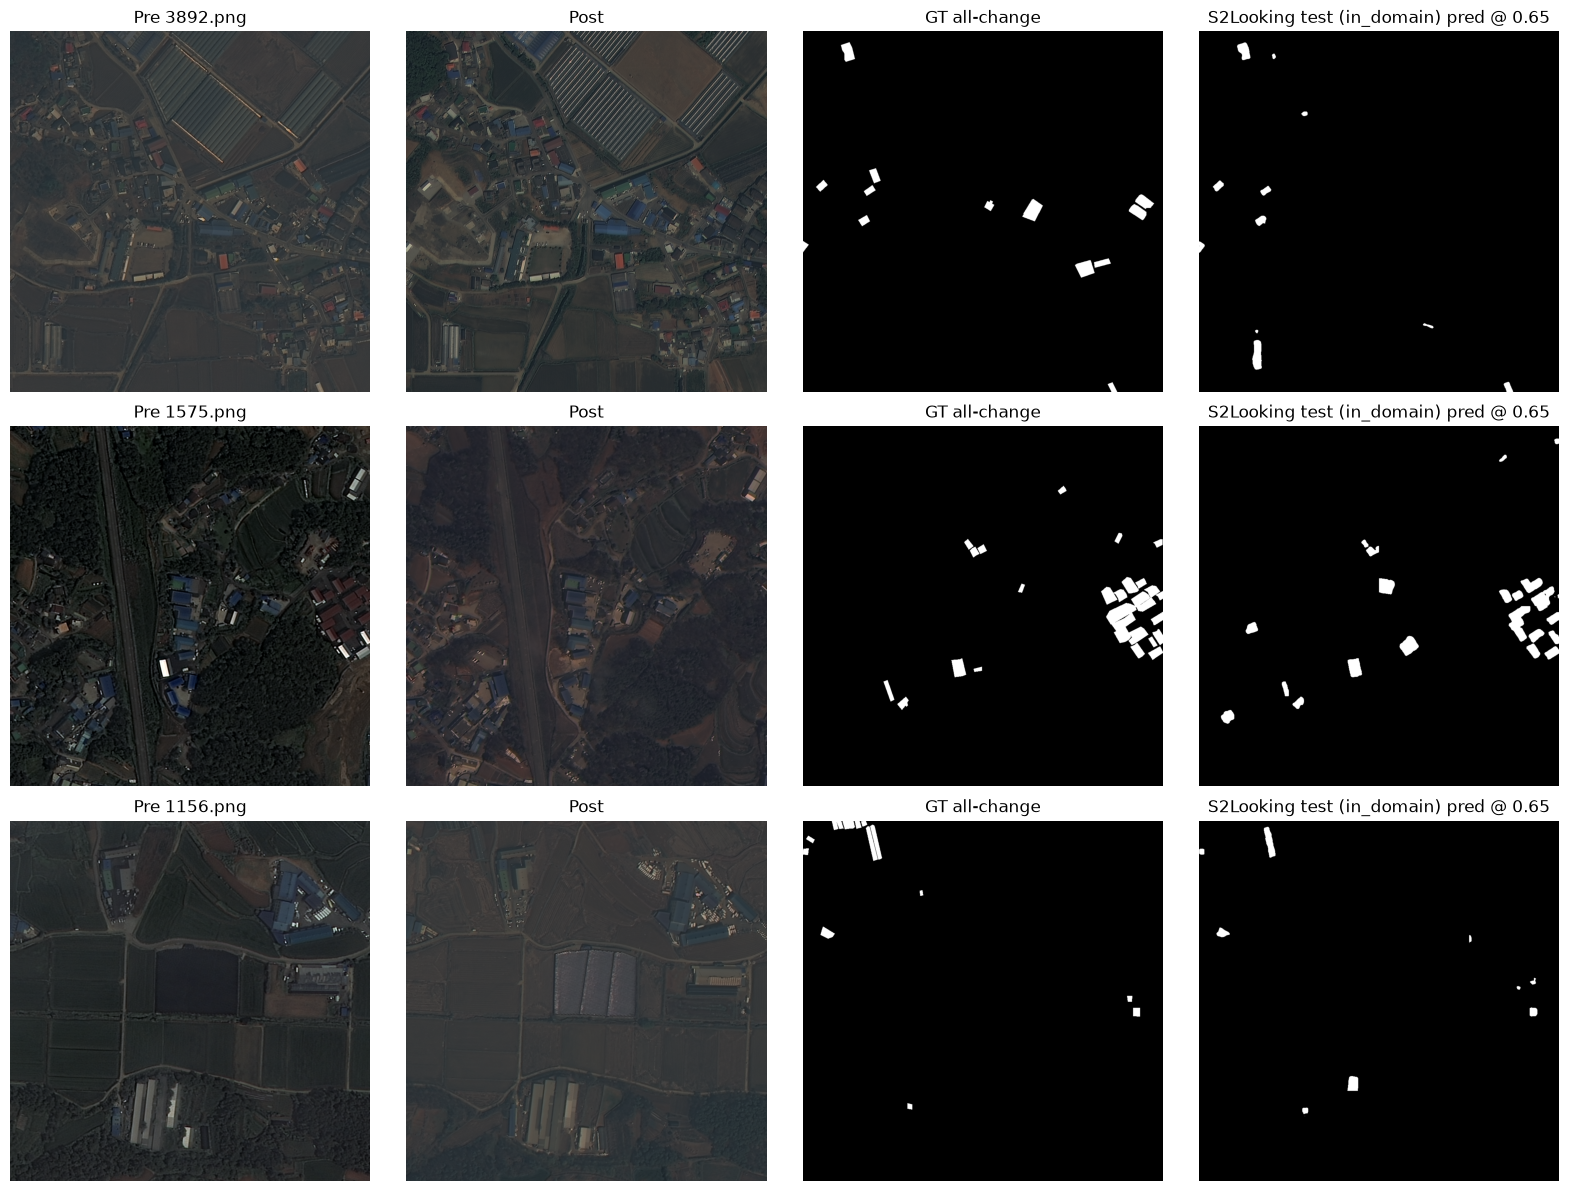


✓ TEST INFERENCE COMPLETE


In [9]:
# ===================== QGMamba-CD: S2Looking test-set inference (cell B) =====================
# PACE version
# Loads the trained S2Looking checkpoint and evaluates on the S2Looking test split.

import gc
import json
from pathlib import Path

# ============================================================
# PRECONDITION CHECK
# ============================================================
# Everything below is built by the QGMamba setup cell (cell A). Without it this
# cell dies on a bare NameError deep in the body, so fail immediately and name
# what is missing. These objects are NOT rebuilt here on purpose: QG_EVAL fixes
# the tile size, stride, TTA flags and threshold grid, so a second definition
# that drifts from cell A would silently change the reported metrics.

_REQUIRED = [
    "build_qgmamba",
    "normalize_state_dict",
    "evaluate_threshold",
    "sweep_thresholds",
    "qg_show",
    "qg_val_ds",
    "qg_test_ds",
    "QG_EVAL",
    "CONTEXT",
    "DEVICE",
    "OUT_DIR",
]

_missing = [
    x for x in _REQUIRED
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the QGMamba setup cell (cell A) before this one.\n"
        f"Missing: {_missing}"
    )


# ============================================================
# CHECKPOINT
# ============================================================

QG_CKPT_PATH = Path(
    "/storage/home/hcoda1/8/asen74/scratch/datasets/"
    "S2Looking/S2Looking/qgmamba_s2looking_best (6).pt"
)

TRAIN_DATASET = "S2Looking"

PROTOCOL = (
    "in_domain"
    if TRAIN_DATASET.upper().startswith("S2")
    else "zero_shot"
)

print("Checkpoint:", QG_CKPT_PATH)
print("Exists    :", QG_CKPT_PATH.exists())

assert QG_CKPT_PATH.exists(), (
    f"Missing checkpoint:\n{QG_CKPT_PATH}"
)


# ============================================================
# LOAD CHECKPOINT
# ============================================================

qg_ckpt = torch.load(
    QG_CKPT_PATH,
    map_location="cpu",
    weights_only=False
)


# ============================================================
# HANDLE BARE STATE-DICT OR WRAPPED CHECKPOINT
# ============================================================

if (
    not isinstance(qg_ckpt, dict)
    or not (
        {"model_state", "ema_state", "state_dict"}
        & set(qg_ckpt)
    )
):
    qg_ckpt = {
        "model_state": qg_ckpt
    }


# ============================================================
# SELECT MODEL / EMA WEIGHTS
# ============================================================

use_ema = (
    qg_ckpt.get("eval_weights", "model") != "model"
    and "ema_state" in qg_ckpt
)

if use_ema:
    zs_state = qg_ckpt["ema_state"]
else:
    zs_state = qg_ckpt.get(
        "model_state",
        qg_ckpt.get("state_dict")
    )


if zs_state is None:
    raise RuntimeError(
        "No model_state/state_dict found in checkpoint."
    )


CKPT_THR = float(
    qg_ckpt.get(
        "threshold",
        0.5
    )
)


# ============================================================
# CHECKPOINT INFORMATION
# ============================================================

best_f1 = qg_ckpt.get(
    "best_f1",
    float("nan")
)

print("\n" + "=" * 70)
print("CHECKPOINT INFORMATION")
print("=" * 70)

print(
    "checkpoint :",
    QG_CKPT_PATH.name
)

print(
    "epoch      :",
    qg_ckpt.get("epoch", "?")
)

try:
    print(
        f"best_f1    : {float(best_f1):.4f}"
    )
except Exception:
    print(
        "best_f1    :",
        best_f1
    )

print(
    "weights    :",
    "ema" if use_ema else "model"
)

print(
    f"ckpt thresh: {CKPT_THR:.3f}"
)

print(
    f"protocol   : {PROTOCOL} "
    f"(trained on {TRAIN_DATASET})"
)


# ============================================================
# BUILD QGMAMBA MODEL
# ============================================================

print("\nBuilding QGMamba model...")

zs_model = build_qgmamba(
    pretrained=False
)


# ============================================================
# LOAD WEIGHTS
# ============================================================

normalized_state = normalize_state_dict(
    zs_state
)

load_result = zs_model.load_state_dict(
    normalized_state,
    strict=True
)

print("✓ Checkpoint loaded successfully")

print(
    "Missing keys    :",
    len(load_result.missing_keys)
)

print(
    "Unexpected keys :",
    len(load_result.unexpected_keys)
)


# ============================================================
# MOVE MODEL TO GPU
# ============================================================

zs_model = (
    zs_model
    .to(DEVICE)
    .eval()
)

print(
    "Model device:",
    next(zs_model.parameters()).device
)


# ============================================================
# FREE UNNECESSARY CHECKPOINT DATA
# ============================================================

for k in (
    "optimizer",
    "scheduler",
    "optimizer_state",
    "scheduler_state",
    "scaler",
    "ema_state",
):
    qg_ckpt.pop(
        k,
        None
    )

del zs_state
del normalized_state

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# AMP CONFIGURATION
# ============================================================

USE_AMP = torch.cuda.is_available()

AMP_DTYPE = (
    "float16"
    if USE_AMP
    else "float32"
)


# ============================================================
# A. TEST AT CHECKPOINT THRESHOLD
# ============================================================

print("\n" + "=" * 70)
print("TEST @ CHECKPOINT THRESHOLD")
print("=" * 70)

zs_at_ckpt_thr = evaluate_threshold(
    zs_model,
    qg_test_ds,
    CKPT_THR,
    QG_EVAL,
    CONTEXT,
    amp=USE_AMP,
    amp_dtype=AMP_DTYPE,
    final=False
)

print(
    json.dumps(
        zs_at_ckpt_thr,
        indent=2
    )
)


# ============================================================
# B. SELECT THRESHOLD ON VALIDATION SET
# ============================================================

print("\n" + "=" * 70)
print("VALIDATION THRESHOLD SWEEP")
print("=" * 70)

zs_threshold, zs_val, _ = sweep_thresholds(
    zs_model,
    qg_val_ds,
    QG_EVAL.thresholds,
    QG_EVAL,
    CONTEXT,
    amp=USE_AMP,
    amp_dtype=AMP_DTYPE
)

print(
    f"\nSelected threshold: "
    f"{zs_threshold:.3f}"
)

print(
    json.dumps(
        zs_val,
        indent=2
    )
)


# ============================================================
# C. TEST USING VALIDATION-SELECTED THRESHOLD
# ============================================================

print("\n" + "=" * 70)
print("TEST @ VALIDATION-SELECTED THRESHOLD")
print("=" * 70)

zs_at_swept_thr = evaluate_threshold(
    zs_model,
    qg_test_ds,
    zs_threshold,
    QG_EVAL,
    CONTEXT,
    amp=USE_AMP,
    amp_dtype=AMP_DTYPE,
    final=False
)


# ============================================================
# REPORT
# ============================================================

report = {

    "checkpoint":
        str(QG_CKPT_PATH),

    "train_dataset":
        TRAIN_DATASET,

    "eval_dataset":
        "S2Looking",

    "protocol":
        PROTOCOL,

    "weights":
        "ema" if use_ema else "model",

    "epoch":
        qg_ckpt.get("epoch"),

    "ckpt_best_f1":
        qg_ckpt.get("best_f1"),

    "test_at_checkpoint_threshold": {
        "threshold":
            CKPT_THR,
        **zs_at_ckpt_thr
    },

    "val_sweep": {
        "threshold":
            zs_threshold,
        **zs_val
    },

    "test_at_swept_threshold": {
        "threshold":
            zs_threshold,
        **zs_at_swept_thr
    },
}


print("\n" + "=" * 70)
print("FINAL REPORT")
print("=" * 70)

print(
    json.dumps(
        report,
        indent=2
    )
)


# ============================================================
# SAVE METRICS
# ============================================================

out_name = (
    f"qgmamba_s2looking_"
    f"{PROTOCOL}_metrics.json"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    OUT_DIR / out_name
)

with open(
    output_path,
    "w"
) as handle:

    json.dump(
        report,
        handle,
        indent=2
    )


print(
    "\n✓ Metrics written to:"
)

print(
    output_path
)


# ============================================================
# VISUALIZE TEST RESULTS
# ============================================================

qg_show(
    zs_model,
    qg_test_ds,
    zs_threshold,
    n=3,
    title=f"S2Looking test ({PROTOCOL})"
)


# ============================================================
# CLEANUP
# ============================================================

del zs_model
del qg_ckpt

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n✓ TEST INFERENCE COMPLETE")

In [ ]:
# ===================== QGMamba-CD: RESUME training on S2Looking (cell C) =====================
# PACE version
# Resumes from OUT_DIR/qgmamba_s2looking_last.pt if it already exists.
# Otherwise starts from the copied qgmamba_s2looking_best (6).pt checkpoint.

import gc
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ============================================================
# 0. CLEAN OLD OBJECTS
# ============================================================

for _stale in (
    "model",
    "optimizer",
    "scheduler",
    "scaler",
    "zs_model",
    "qg_model",
    "qg_optimizer",
    "qg_scheduler",
    "qg_scaler",
    "qg_ema",
):
    if _stale in globals():
        del globals()[_stale]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# seed_everything() comes from qgmamba_cd.distributed and is normally bound by
# the QGMamba setup cell. Re-resolve it here so this cell also works when it is
# run on its own, or after a kernel restart, instead of raising NameError.

try:
    seed_everything

except NameError:

    try:
        from qgmamba_cd.distributed import seed_everything

    except Exception:

        def seed_everything(seed):

            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


# ============================================================
# 1. REQUIRED OBJECT CHECK
# ============================================================

_REQUIRED = [
    "QG_CFG_PATH",
    "QG_TILE",
    "QG_EVAL",
    "CONTEXT",
    "qg_val_ds",
    "train_ds",
    "OUT_DIR",
    "DEVICE",
    "load_config",
    "QGMambaDiffCD",
    "ModelEMA",
    "FullLoss",
    "normalize_state_dict",
    "save_checkpoint",
    "build_layerwise_parameter_groups",
    "sweep_thresholds",
]

_missing = [
    x for x in _REQUIRED
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the earlier setup/dataset cells first.\n"
        f"Missing: {_missing}"
    )


# ============================================================
# 2. PACE CHECKPOINT PATHS
# ============================================================

S2_ROOT = Path(
    "/storage/home/hcoda1/8/asen74/scratch/"
    "datasets/S2Looking/S2Looking"
)

ORIGINAL_BEST_PATH = (
    S2_ROOT / "qgmamba_s2looking_best (6).pt"
)

QG_BEST_PATH = (
    OUT_DIR / "qgmamba_s2looking_best.pt"
)

QG_LAST_PATH = (
    OUT_DIR / "qgmamba_s2looking_last.pt"
)


# If we have already resumed training once,
# resume from the newest LAST checkpoint.
# Otherwise begin from the copied best checkpoint.

if QG_LAST_PATH.exists():

    QG_RESUME_PATH = QG_LAST_PATH

    print(
        "Using latest resumed checkpoint:"
    )

else:

    QG_RESUME_PATH = ORIGINAL_BEST_PATH

    print(
        "Using original S2Looking checkpoint:"
    )

print(QG_RESUME_PATH)

assert QG_RESUME_PATH.exists(), (
    f"\nMissing checkpoint:\n{QG_RESUME_PATH}"
)


# ============================================================
# 3. TRAINING CONFIG
# ============================================================

# ------------------------------------------------------------------------
# FINE-TUNE SCHEDULE
#
# The epoch-83 checkpoint is converged. The previous resume built a FRESH
# OneCycle over the remaining 37 epochs with pct_start=0.05, which ramped the
# LR back to 1.0e-4 (the from-scratch value) by epoch 86 and held it there.
# That is re-heating, not fine-tuning, and the log shows it: train loss rose
# 1.09 -> 1.13 and val F1 fell to 0.6586 before crawling back to 0.6629.
#
# Everything below anneals from a low peak instead. Model and loss structure
# are untouched -- these are optimiser, schedule, precision and EMA settings.
# ------------------------------------------------------------------------

# TOTAL epochs, including epochs already completed
QG_EPOCHS = 140

QG_BATCH = 8

# Peak LR for the fine-tune cycle. Was 1.0e-4.
QG_LR = 2.5e-5

QG_PATIENCE = 18

QG_EMA_WARMUP = 8

# Every step rather than every 2 -> smoother shadow weights at plateau.
QG_EMA_UPDATE_EVERY = 1

QG_EMA_REFERENCE_BATCH = 8

# Longer EMA horizon for fine-tuning. None -> keep the YAML value.
# 0.9999 averages roughly 10k steps, about 6 epochs at 1750 steps/epoch.
QG_EMA_DECAY = 0.9999

# Loss balance. Was 4.0. Together with CROP_NONEMPTY_P this is the calibration
# story: val precision 0.643 < recall 0.679 and a swept threshold of 0.65 are
# what an over-weighted positive class looks like. A well-calibrated model on
# this data should sweep to something nearer 0.5.
#
# 3.0 rather than 2.5 because the crop ratio already moved in the same
# direction; taking both to their extremes risks over-correcting into a
# recall collapse that costs more F1 than the precision gain returns.
QG_POS_WEIGHT = 3.0

# Epochs after resume during which a non-improving epoch does NOT consume
# patience. The crop ratio and pos_weight changes shift the training
# distribution, and EMA needs ~6 epochs to catch up, so the first epochs are
# expected to sit below the 0.4958 baseline. Without this the run would early
# stop while it is still re-converging.
QG_FT_GRACE = 8

# Keep the N best epochs on disk for weight averaging after training.
QG_TOPK = 3

# None -> keep the YAML weight_decay. Zero-decay groups (norms, biases) are
# preserved either way.
QG_WEIGHT_DECAY = None

# Force a fresh gentle cycle rather than restoring the old OneCycle state.
QG_FRESH_SCHEDULE = True

QG_PCT_START = 0.02           # ~1 epoch of warmup, was 5% of the horizon
QG_DIV_FACTOR = 10.0          # start at QG_LR / 10, was / 25
QG_FINAL_DIV_FACTOR = 1.0e4   # anneal to ~2.5e-9 rather than stopping at 1e-7

QG_LR_SCALE = 1.0             # uniform multiplier on the layerwise group LRs

# bfloat16 has fp32 dynamic range, so the GradScaler and its overflow/skip
# path disappear entirely. Falls back to float16 on pre-Ampere GPUs.
QG_PREFER_BF16 = True

# Checkpointing
QG_SNAPSHOT_EVERY = 10        # epoch-tagged snapshot every N epochs, 0 = off
QG_INTRA_EPOCH_SAVE = None    # e.g. 500 -> also save every 500 steps


# Inputs are a fixed 256x256, so let cuDNN pick and cache the fastest kernels.
# TF32 covers the fp32 ops that sit outside autocast.
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


QG_BF16 = (
    QG_PREFER_BF16
    and torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

QG_AMP_DTYPE = (
    torch.bfloat16
    if QG_BF16
    else torch.float16
)

print(
    "AMP dtype       :",
    "bfloat16" if QG_BF16 else "float16"
)


# ============================================================
# 4. LOAD YAML CONFIG
# ============================================================

qg_cfg = load_config(
    QG_CFG_PATH
)

qg_cfg.train.epochs = QG_EPOCHS
qg_cfg.train.batch_size = QG_BATCH
qg_cfg.train.learning_rate = QG_LR

qg_cfg.train.amp_dtype = (
    "bfloat16"
    if QG_BF16
    else "float16"
)

# Single point of truth for the EMA horizon: ModelEMA in section 8 and
# qg_decay in section 16 both read this.
if QG_EMA_DECAY is not None:
    qg_cfg.train.ema_decay = QG_EMA_DECAY

if QG_WEIGHT_DECAY is not None:
    qg_cfg.train.weight_decay = QG_WEIGHT_DECAY

# Do not download pretrained encoder.
# Model weights come from checkpoint.
qg_cfg.model.pretrained = False


# ============================================================
# 5. LOAD CHECKPOINT
# ============================================================

print("\nLoading checkpoint...")

_raw_ckpt = torch.load(
    QG_RESUME_PATH,
    map_location="cpu",
    weights_only=False
)


# Handle full checkpoint OR bare state_dict
if (
    isinstance(_raw_ckpt, dict)
    and (
        "model_state" in _raw_ckpt
        or "state_dict" in _raw_ckpt
        or "ema_state" in _raw_ckpt
    )
):

    qg_ckpt = _raw_ckpt

else:

    print(
        "Checkpoint appears to be a bare state_dict."
    )

    qg_ckpt = {
        "model_state": _raw_ckpt
    }


# ============================================================
# 6. DETERMINE START EPOCH
# ============================================================

_completed_epoch = int(
    qg_ckpt.get(
        "epoch",
        0
    ) or 0
)

qg_start_epoch = (
    _completed_epoch + 1
)


def _safe_float(value, default=-1.0):

    try:
        if value is None:
            return default

        return float(value)

    except Exception:
        return default


def _safe_int(value, default=0):

    try:
        if value is None:
            return default

        return int(value)

    except Exception:
        return default


print("\n" + "=" * 70)
print("RESUME INFORMATION")
print("=" * 70)

print(
    "checkpoint      :",
    QG_RESUME_PATH.name
)

print(
    "completed epoch :",
    _completed_epoch
)

print(
    "starting epoch  :",
    qg_start_epoch
)

print(
    "best IoU        :",
    _safe_float(
        qg_ckpt.get("best_iou"),
        float("nan")
    )
)

print(
    "best epoch      :",
    qg_ckpt.get(
        "best_epoch",
        "?"
    )
)

print(
    "eval weights    :",
    qg_ckpt.get(
        "eval_weights",
        "unknown"
    )
)


if qg_start_epoch > QG_EPOCHS:

    raise RuntimeError(
        f"Checkpoint is already at epoch "
        f"{_completed_epoch}.\n"
        f"QG_EPOCHS={QG_EPOCHS}.\n\n"
        f"Increase QG_EPOCHS above "
        f"{_completed_epoch} to continue training."
    )


# ============================================================
# 7. BUILD MODEL
# ============================================================

print("\nBuilding QGMamba...")

qg_model = QGMambaDiffCD(
    qg_cfg.model
).to(
    DEVICE
)


# Get correct model weights
if "model_state" in qg_ckpt:

    _model_sd = qg_ckpt[
        "model_state"
    ]

elif "state_dict" in qg_ckpt:

    _model_sd = qg_ckpt[
        "state_dict"
    ]

else:

    raise RuntimeError(
        "No model_state/state_dict found."
    )


_model_sd = normalize_state_dict(
    _model_sd
)

load_result = qg_model.load_state_dict(
    _model_sd,
    strict=True
)

print("✓ Model weights restored")

print(
    "missing keys    :",
    len(load_result.missing_keys)
)

print(
    "unexpected keys :",
    len(load_result.unexpected_keys)
)

del _model_sd


# ============================================================
# 8. RESTORE EMA
# ============================================================

qg_ema = ModelEMA(
    qg_model,
    decay=qg_cfg.train.ema_decay
)


if "ema_state" in qg_ckpt:

    _ema_sd = normalize_state_dict(
        qg_ckpt["ema_state"]
    )

    try:

        qg_ema.load_state_dict(
            _ema_sd
        )

    except (
        AttributeError,
        TypeError,
        RuntimeError
    ):

        qg_ema.ema.load_state_dict(
            _ema_sd,
            strict=True
        )

    print("✓ EMA shadow weights restored")

    del _ema_sd

else:

    print(
        "WARNING: checkpoint has no ema_state."
    )

    print(
        "EMA initialized from current model."
    )


# ============================================================
# 9. LOSS
# ============================================================

qg_criterion = FullLoss(
    qg_cfg.loss,
    pos_weight=QG_POS_WEIGHT
).to(
    DEVICE
)


# ============================================================
# 10. OPTIMIZER
# ============================================================

qg_param_groups, qg_max_lrs = (
    build_layerwise_parameter_groups(
        qg_model,
        qg_cfg
    )
)

# Uniform multiplier, so the layerwise decay ratios the repo assigned are
# preserved exactly -- only the absolute scale moves.
qg_max_lrs = [
    float(lr) * QG_LR_SCALE
    for lr in qg_max_lrs
]

print(
    f"layerwise peak LR: "
    f"{min(qg_max_lrs):.2e} .. {max(qg_max_lrs):.2e} "
    f"across {len(qg_max_lrs)} groups"
)

qg_optimizer = torch.optim.AdamW(
    qg_param_groups,
    lr=qg_cfg.train.learning_rate,
    weight_decay=qg_cfg.train.weight_decay
)


if "optimizer" in qg_ckpt:

    try:

        qg_optimizer.load_state_dict(
            qg_ckpt["optimizer"]
        )

        print(
            "✓ AdamW optimizer state restored"
        )

    except Exception as e:

        print(
            "WARNING: optimizer state could "
            "not be restored."
        )

        print(
            "Starting optimizer fresh:"
        )

        print(e)

else:

    print(
        "No optimizer state in checkpoint "
        "— optimizer starts fresh."
    )


# load_state_dict above restores the OLD weight_decay into every param group,
# so a changed QG_WEIGHT_DECAY would silently do nothing without this. Groups
# that were deliberately set to zero decay (norms, biases) stay at zero.
if QG_WEIGHT_DECAY is not None:

    for _group in qg_optimizer.param_groups:

        if _group.get("weight_decay", 0.0) > 0.0:

            _group["weight_decay"] = QG_WEIGHT_DECAY

    print(
        f"weight decay reapplied: {QG_WEIGHT_DECAY}"
    )


# ============================================================
# 11. TRAIN LOADER
# ============================================================

qg_train_loader = DataLoader(

    train_ds,

    batch_size=QG_BATCH,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available(),

    drop_last=True,

    # Each sample reads five full 1024x1024 files, so the loader is the likely
    # bottleneck at 0.37 s/step. Keeping workers alive across epochs removes
    # the per-epoch respawn, and a deeper prefetch hides the read latency.
    persistent_workers=NUM_WORKERS > 0,

    prefetch_factor=(
        4
        if NUM_WORKERS > 0
        else None
    )
)


_steps_per_epoch = len(
    qg_train_loader
)

print(
    "\nTraining batches per epoch:",
    _steps_per_epoch
)


# ============================================================
# 12. SCHEDULER
# ============================================================

_sched_ckpt = qg_ckpt.get(
    "scheduler"
)

_ckpt_total = (
    _sched_ckpt.get(
        "total_steps"
    )
    if isinstance(
        _sched_ckpt,
        dict
    )
    else None
)

_planned_total = (
    _steps_per_epoch
    * QG_EPOCHS
)


# QG_FRESH_SCHEDULE forces the gentle-anneal branch below. Restoring the old
# OneCycle state would put the LR back on the from-scratch curve.
if (
    not QG_FRESH_SCHEDULE
    and _sched_ckpt is not None
    and _ckpt_total == _planned_total
):

    qg_scheduler = (
        torch.optim.lr_scheduler.OneCycleLR(

            qg_optimizer,

            max_lr=qg_max_lrs,

            epochs=QG_EPOCHS,

            steps_per_epoch=
                _steps_per_epoch,

            pct_start=0.1,

            div_factor=25.0,

            final_div_factor=1000.0,

            anneal_strategy="cos"
        )
    )


    try:

        qg_scheduler.load_state_dict(
            _sched_ckpt
        )

        qg_step = int(
            _sched_ckpt.get(
                "last_epoch",
                (
                    qg_start_epoch - 1
                )
                * _steps_per_epoch
            )
        )

        print(
            f"✓ OneCycle resumed at "
            f"step {qg_step}/"
            f"{_planned_total}"
        )

    except Exception as e:

        print(
            "Scheduler restore failed:"
        )

        print(e)

        qg_step = (
            qg_start_epoch - 1
        ) * _steps_per_epoch


else:

    _remaining = (
        QG_EPOCHS
        - qg_start_epoch
        + 1
    )

    qg_scheduler = (
        torch.optim.lr_scheduler.OneCycleLR(

            qg_optimizer,

            max_lr=qg_max_lrs,

            epochs=_remaining,

            steps_per_epoch=
                _steps_per_epoch,

            pct_start=QG_PCT_START,

            div_factor=QG_DIV_FACTOR,

            final_div_factor=QG_FINAL_DIV_FACTOR,

            anneal_strategy="cos"
        )
    )

    qg_step = (
        qg_start_epoch - 1
    ) * _steps_per_epoch


    print(
        "Fresh fine-tune cycle over "
        f"{_remaining} remaining epochs."
    )

    print(
        f"  warmup    : "
        f"{QG_PCT_START * _remaining:.1f} epochs"
    )

    print(
        f"  LR path   : "
        f"{max(qg_max_lrs) / QG_DIV_FACTOR:.2e}"
        f" -> {max(qg_max_lrs):.2e}"
        f" -> {max(qg_max_lrs) / QG_FINAL_DIV_FACTOR:.2e}"
    )


# ============================================================
# 13. GRAD SCALER
# ============================================================

USE_AMP = torch.cuda.is_available()

# bfloat16 needs no loss scaling. With enabled=False the scale/unscale_/step/
# update calls in the loop below become pass-throughs, so the training loop
# itself is byte-identical either way.
qg_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP and not QG_BF16
)


if (
    "scaler" in qg_ckpt
    and USE_AMP
    and not QG_BF16
):

    try:

        qg_scaler.load_state_dict(
            qg_ckpt["scaler"]
        )

        print(
            "✓ AMP scaler restored"
        )

    except Exception as e:

        print(
            "WARNING: scaler state "
            "not restored:"
        )

        print(e)


# ============================================================
# 14. RANDOM 256x256 CROP
# ============================================================

def random_crop_pair(
    images6,
    masks3
):

    """
    images6:
        (B,6,H,W)

    masks3:
        (B,3,H,W)

    Returns:
        image A
        image B
        all-change target
    """

    _, _, height, width = (
        images6.shape
    )


    if (
        height < QG_TILE
        or width < QG_TILE
    ):

        raise ValueError(
            f"Input size {height}x{width} "
            f"is smaller than QG_TILE="
            f"{QG_TILE}"
        )


    list_a = []
    list_b = []
    list_t = []


    for i in range(
        images6.shape[0]
    ):

        y = random.randint(
            0,
            height - QG_TILE
        )

        x = random.randint(
            0,
            width - QG_TILE
        )


        list_a.append(
            images6[
                i,
                :3,
                y:y + QG_TILE,
                x:x + QG_TILE
            ]
        )


        list_b.append(
            images6[
                i,
                3:,
                y:y + QG_TILE,
                x:x + QG_TILE
            ]
        )


        list_t.append(
            masks3[
                i,
                0:1,
                y:y + QG_TILE,
                x:x + QG_TILE
            ]
        )


    return (
        torch.stack(list_a),
        torch.stack(list_b),
        torch.stack(list_t)
    )


# ============================================================
# 15. HISTORY / BEST VALUES
# ============================================================

_hist_keys = (
    "epoch",
    "train_loss",
    "threshold",
    "val_precision",
    "val_recall",
    "val_f1",
    "val_iou",
    "eval_weights",
)


_existing_history = (
    qg_ckpt.get("history")
    or {}
)


qg_history = {

    k: list(
        _existing_history.get(
            k,
            []
        )
    )

    for k in _hist_keys
}


qg_best_iou = _safe_float(
    qg_ckpt.get("best_iou"),
    -1.0
)

qg_best_f1 = _safe_float(
    qg_ckpt.get("best_f1"),
    -1.0
)

qg_best_epoch = _safe_int(
    qg_ckpt.get("best_epoch"),
    0
)

qg_best_threshold = _safe_float(
    qg_ckpt.get("threshold"),
    0.5
)


# Recover best from history if necessary
if qg_history["val_iou"]:

    _i = int(
        np.argmax(
            qg_history[
                "val_iou"
            ]
        )
    )

    _history_best_iou = float(
        qg_history[
            "val_iou"
        ][_i]
    )


    if (
        _history_best_iou
        > qg_best_iou
    ):

        qg_best_iou = (
            _history_best_iou
        )

        qg_best_f1 = float(
            qg_history[
                "val_f1"
            ][_i]
        )

        qg_best_epoch = int(
            qg_history[
                "epoch"
            ][_i]
        )

        qg_best_threshold = float(
            qg_history[
                "threshold"
            ][_i]
        )


        print(
            "Best trackers corrected "
            "from history:"
        )

        print(
            f"IoU {qg_best_iou:.4f} "
            f"@ epoch "
            f"{qg_best_epoch}"
        )


# ============================================================
# 16. EMA DECAY
# ============================================================

qg_decay = (

    (
        qg_cfg.train.ema_decay
        ** (
            QG_BATCH
            / QG_EMA_REFERENCE_BATCH
        )
    )

    ** QG_EMA_UPDATE_EVERY
)


qg_stall = 0

# (val_iou, epoch, path) for the QG_TOPK best epochs, newest sort each epoch.
qg_topk = []


# ============================================================
# 16b. ATOMIC CHECKPOINT SAVE
# ============================================================

def qg_save(path, state):

    """
    Write to a .tmp file and rename into place.

    torch.save streams to disk, so a walltime kill or a full scratch quota
    partway through a direct write leaves a truncated file where the good
    checkpoint used to be. os.replace is atomic on POSIX, so the destination
    is either the previous checkpoint or the complete new one, never a
    half-written one.

    Returns the file size in MB.
    """

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    tmp = path.with_name(
        path.name + ".tmp"
    )

    save_checkpoint(
        tmp,
        state
    )

    os.replace(
        tmp,
        path
    )

    return path.stat().st_size / 1e6


def qg_state(epoch, threshold, val_metrics, use_ema):

    """Assemble the resume payload. Same keys the loader in section 5 reads."""

    return {

        "epoch":
            int(epoch),

        "model_state":
            qg_model.state_dict(),

        "ema_state":
            qg_ema.state_dict(),

        "optimizer":
            qg_optimizer.state_dict(),

        "scheduler":
            qg_scheduler.state_dict(),

        "scaler":
            qg_scaler.state_dict(),

        "threshold":
            threshold,

        "val_metrics":
            val_metrics,

        "best_f1":
            qg_best_f1,

        "best_epoch":
            qg_best_epoch,

        "best_iou":
            qg_best_iou,

        "history":
            qg_history,

        "eval_weights":
            (
                "ema"
                if use_ema
                else "model"
            ),

        "resumed_from":
            str(
                QG_RESUME_PATH
            ),
    }


# Release original checkpoint copy
del qg_ckpt
del _raw_ckpt

gc.collect()


print("\n" + "=" * 70)

print(
    f"TRAINING EPOCHS "
    f"{qg_start_epoch}.."
    f"{QG_EPOCHS}"
)

print(
    f"Baseline best IoU: "
    f"{qg_best_iou:.4f}"
)

print("=" * 70)


# ============================================================
# 17. TRAIN
# ============================================================

for epoch in range(
    qg_start_epoch,
    QG_EPOCHS + 1
):

    qg_model.train()

    epoch_start = time.time()

    epoch_losses = []


    progress = tqdm(

        qg_train_loader,

        desc=(
            f"qgmamba "
            f"{epoch:02d}/"
            f"{QG_EPOCHS}"
        ),

        leave=False
    )


    for images6, masks3 in progress:


        image_a, image_b, target = (
            random_crop_pair(
                images6,
                masks3
            )
        )


        image_a = image_a.to(
            DEVICE,
            non_blocking=True
        )

        image_b = image_b.to(
            DEVICE,
            non_blocking=True
        )

        target = target.to(
            DEVICE,
            non_blocking=True
        )


        qg_optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(

            device_type="cuda",

            enabled=USE_AMP,

            dtype=QG_AMP_DTYPE

        ):

            outputs = qg_model(
                image_a,
                image_b,
                target
            )

            loss = qg_criterion(
                *outputs,
                target
            )


        if not torch.isfinite(loss):

            print(
                "WARNING: non-finite "
                "loss; skipping batch."
            )

            continue


        qg_scaler.scale(
            loss
        ).backward()


        qg_scaler.unscale_(
            qg_optimizer
        )


        torch.nn.utils.clip_grad_norm_(

            qg_model.parameters(),

            max_norm=
                qg_cfg.train.grad_clip
        )


        qg_scaler.step(
            qg_optimizer
        )

        qg_scaler.update()


        if (
            qg_scheduler.last_epoch
            < qg_scheduler.total_steps - 1
        ):

            qg_scheduler.step()


        qg_step += 1


        if (
            qg_step
            % QG_EMA_UPDATE_EVERY
            == 0
        ):

            qg_ema.update(
                qg_model,
                decay=qg_decay
            )


        # Optional mid-epoch resume point. Epochs run ~11 min, so a walltime
        # kill otherwise costs the whole epoch. epoch-1 is recorded so a
        # resume re-runs this epoch from its start.
        if (
            QG_INTRA_EPOCH_SAVE
            and qg_step % QG_INTRA_EPOCH_SAVE == 0
        ):

            qg_save(
                QG_LAST_PATH,
                qg_state(
                    epoch - 1,
                    qg_best_threshold,
                    {},
                    True
                )
            )


        epoch_losses.append(
            float(
                loss.item()
            )
        )


        progress.set_postfix(

            loss=(
                f"{np.mean(epoch_losses):.4f}"
            )
        )


    # ========================================================
    # VALIDATE
    # ========================================================

    if not epoch_losses:

        print(
            f"Epoch {epoch}: "
            "no finite training batches."
        )

        continue


    use_ema = (
        epoch
        > QG_EMA_WARMUP
    )


    eval_model = (
        qg_ema.ema
        if use_ema
        else qg_model
    )


    threshold, val_metrics, _ = (
        sweep_thresholds(

            eval_model,

            qg_val_ds,

            QG_EVAL.thresholds,

            QG_EVAL,

            CONTEXT,

            amp=USE_AMP,

            amp_dtype="float16"
        )
    )


    threshold = float(
        threshold
    )


    # ========================================================
    # UPDATE HISTORY
    # ========================================================

    qg_history[
        "epoch"
    ].append(
        int(epoch)
    )


    qg_history[
        "train_loss"
    ].append(
        float(
            np.mean(
                epoch_losses
            )
        )
    )


    qg_history[
        "threshold"
    ].append(
        threshold
    )


    for key in (
        "precision",
        "recall",
        "f1",
        "iou"
    ):

        qg_history[
            f"val_{key}"
        ].append(
            float(
                val_metrics[key]
            )
        )


    qg_history[
        "eval_weights"
    ].append(
        "ema"
        if use_ema
        else "model"
    )


    # ========================================================
    # CHECK IMPROVEMENT FIRST
    # ========================================================

    improved = (
        float(
            val_metrics["iou"]
        )
        > qg_best_iou
    )


    if improved:

        qg_best_iou = float(
            val_metrics["iou"]
        )

        qg_best_f1 = float(
            val_metrics["f1"]
        )

        qg_best_epoch = int(
            epoch
        )

        qg_best_threshold = (
            threshold
        )

        qg_stall = 0

    else:

        qg_stall += 1


    # Raw -> EMA transition should
    # not consume patience.
    if (
        epoch
        == QG_EMA_WARMUP + 1
    ):

        qg_stall = 0


    # Nor should the re-convergence window after a distribution change.
    if (
        epoch
        < qg_start_epoch + QG_FT_GRACE
    ):

        qg_stall = 0


    # ========================================================
    # SAVE STATE
    # ========================================================

    state = qg_state(
        epoch,
        threshold,
        val_metrics,
        use_ema
    )


    # Always save latest state
    _last_mb = qg_save(
        QG_LAST_PATH,
        state
    )


    # Save best separately
    if improved:

        _best_mb = qg_save(
            QG_BEST_PATH,
            state
        )

        print(
            f"  saved best -> "
            f"{QG_BEST_PATH.name} "
            f"({_best_mb:.0f} MB)"
        )


    # Epoch-tagged snapshot, so a bad best/last is not the end of the run
    if (
        QG_SNAPSHOT_EVERY
        and epoch % QG_SNAPSHOT_EVERY == 0
    ):

        qg_save(
            OUT_DIR
            / f"qgmamba_s2looking_ep{epoch:03d}.pt",
            state
        )


    # ========================================================
    # TOP-K RETENTION FOR WEIGHT AVERAGING
    # ========================================================
    # A low-LR fine-tune keeps every late epoch inside one loss basin, so the
    # top epochs are points around a single minimum rather than different
    # solutions. Averaging them cancels the per-epoch gradient noise that no
    # single checkpoint can shed. Cell D builds and scores the average.

    _topk_path = (
        OUT_DIR
        / f"qgmamba_s2looking_top_{epoch:03d}.pt"
    )

    qg_topk.append(
        (
            float(val_metrics["iou"]),
            int(epoch),
            _topk_path
        )
    )

    qg_topk.sort(
        key=lambda t: -t[0]
    )


    _keep = qg_topk[:QG_TOPK]
    _drop = qg_topk[QG_TOPK:]


    if any(
        e == epoch
        for _, e, _ in _keep
    ):

        qg_save(
            _topk_path,
            state
        )


    for _, _, _p in _drop:

        if _p.exists():

            _p.unlink()


    qg_topk = _keep


    # ========================================================
    # STATUS
    # ========================================================

    print(

        f"qgmamba "
        f"{epoch:02d}/"
        f"{QG_EPOCHS}"

        f" | loss "
        f"{np.mean(epoch_losses):.4f}"

        f" | val IoU "
        f"{val_metrics['iou']:.4f}"

        f" F1 "
        f"{val_metrics['f1']:.4f}"

        f" @ thr "
        f"{threshold:.2f}"

        f" ({'ema' if use_ema else 'raw'})"

        f" | best IoU "
        f"{qg_best_iou:.4f}"

        f" (ep {qg_best_epoch})"

        f"{' -> BEST UPDATED' if improved else ''}"

        f" | "
        f"{time.time() - epoch_start:.0f}s"
    )


    # ========================================================
    # EARLY STOP
    # ========================================================

    if (
        qg_stall
        >= QG_PATIENCE
    ):

        print(
            f"Early stopping: "
            f"no val IoU improvement "
            f"for {QG_PATIENCE} epochs."
        )

        break


# ============================================================
# 18. SAVE HISTORY
# ============================================================

history_path = (
    OUT_DIR
    / "qgmamba_s2looking_history.csv"
)

pd.DataFrame(
    qg_history
).to_csv(
    history_path,
    index=False
)

# ========================================================
# STATUS — PRINT ALL METRICS
# ========================================================

print(
    f"qgmamba {epoch:02d}/{QG_EPOCHS}"
    f" | loss {np.mean(epoch_losses):.4f}"
    f" | Precision {val_metrics['precision']:.4f}"
    f" | Recall {val_metrics['recall']:.4f}"
    f" | F1 {val_metrics['f1']:.4f}"
    f" | IoU {val_metrics['iou']:.4f}"
    f" | thr {threshold:.2f}"
    f" | {'EMA' if use_ema else 'RAW'}"
    f" | best IoU {qg_best_iou:.4f}"
    f" (ep {qg_best_epoch})"
    f"{' -> BEST UPDATED' if improved else ''}"
    f" | {time.time() - epoch_start:.0f}s"
)


# ============================================================
# 19. CHECKPOINT VERIFICATION
# ============================================================

print("\n" + "=" * 70)
print("CHECKPOINTS ON DISK")
print("=" * 70)

for _p in (
    QG_BEST_PATH,
    QG_LAST_PATH
):

    if _p.exists():

        print(
            f"  {_p.name:38s} "
            f"{_p.stat().st_size / 1e6:8.1f} MB"
        )

    else:

        print(
            f"  MISSING: {_p}"
        )


for _p in sorted(
    OUT_DIR.glob(
        "qgmamba_s2looking_ep*.pt"
    )
):

    print(
        f"  {_p.name:38s} "
        f"{_p.stat().st_size / 1e6:8.1f} MB"
    )


print("\nTop-%d epochs retained for weight averaging:" % QG_TOPK)

for _iou, _ep, _p in qg_topk:

    print(
        f"  epoch {_ep:3d}  val IoU {_iou:.4f}  "
        f"{'present' if _p.exists() else 'MISSING'}"
    )


# Confirm the best checkpoint actually reloads before trusting the run
_verify = torch.load(
    QG_BEST_PATH,
    map_location="cpu",
    weights_only=False
)

print(
    f"\nbest checkpoint reloads OK: "
    f"epoch {_verify.get('epoch')}, "
    f"eval_weights {_verify.get('eval_weights')}, "
    f"keys {len(_verify)}"
)

del _verify
gc.collect()

print(
    f"\nbest val IoU {qg_best_iou:.4f} / "
    f"F1 {qg_best_f1:.4f} @ epoch {qg_best_epoch}, "
    f"threshold {qg_best_threshold:.3f}"
)

print(
    "\nRun the final-evaluation cell (cell D) next: overlap tiling at "
    "stride 128 plus D4 TTA is where the remaining points are."
)       

Using latest resumed checkpoint:
/storage/home/hcoda1/8/asen74/scratch/S2Looking_results/qgmamba_s2looking_last.pt
AMP dtype       : bfloat16

Loading checkpoint...

RESUME INFORMATION
checkpoint      : qgmamba_s2looking_last.pt
completed epoch : 92
starting epoch  : 93
best IoU        : 0.4957738965742853
best epoch      : 86
eval weights    : ema

Building QGMamba...
✓ Model weights restored
missing keys    : 0
unexpected keys : 0
✓ EMA shadow weights restored
layerwise peak LR: 1.60e-06 .. 2.50e-05 across 3 groups
✓ AdamW optimizer state restored

Training batches per epoch: 1750
Fresh fine-tune cycle over 48 remaining epochs.
  warmup    : 1.0 epochs
  LR path   : 2.50e-06 -> 2.50e-05 -> 2.50e-09

TRAINING EPOCHS 93..140
Baseline best IoU: 0.4958


  saved best -> qgmamba_s2looking_best.pt (896 MB)
qgmamba 93/140 | loss 1.0643 | val IoU 0.5241 F1 0.6878 @ thr 0.68 (ema) | best IoU 0.5241 (ep 93) -> BEST UPDATED | 1476s


  saved best -> qgmamba_s2looking_best.pt (896 MB)
qgmamba 94/140 | loss 1.0485 | val IoU 0.5257 F1 0.6891 @ thr 0.65 (ema) | best IoU 0.5257 (ep 94) -> BEST UPDATED | 1491s


  saved best -> qgmamba_s2looking_best.pt (896 MB)
qgmamba 95/140 | loss 1.0311 | val IoU 0.5270 F1 0.6903 @ thr 0.65 (ema) | best IoU 0.5270 (ep 95) -> BEST UPDATED | 1508s


  saved best -> qgmamba_s2looking_best.pt (896 MB)
qgmamba 96/140 | loss 1.0289 | val IoU 0.5285 F1 0.6915 @ thr 0.65 (ema) | best IoU 0.5285 (ep 96) -> BEST UPDATED | 1512s


  saved best -> qgmamba_s2looking_best.pt (896 MB)
qgmamba 97/140 | loss 1.0125 | val IoU 0.5294 F1 0.6923 @ thr 0.62 (ema) | best IoU 0.5294 (ep 97) -> BEST UPDATED | 1540s


Validation:  18%|█▊        | 89/500 [01:11<04:56,  1.38it/s]                    

In [ ]:
# ===================== QGMamba-CD: final S2Looking evaluation (cell D) =====================
# Loads the best-val-IoU checkpoint from cell C, re-sweeps the full threshold
# grid on val, then reports test metrics with the repo's final protocol
# (overlap tiling stride 128 + horizontal/vertical-flip TTA) and shows
# predictions + training curves.
import json
import gc

# ============================================================
# PRECONDITION CHECK
# ============================================================
# Everything below is built by the QGMamba setup cell (cell A). Without it this
# cell dies on a bare NameError deep in the body, so fail immediately and name
# what is missing. These objects are NOT rebuilt here on purpose: QG_EVAL fixes
# the tile size, stride, TTA flags and threshold grid, so a second definition
# that drifts from cell A would silently change the reported metrics.

_REQUIRED = [
    "build_qgmamba",
    "normalize_state_dict",
    "evaluate_threshold",
    "sweep_thresholds",
    "qg_show",
    "qg_val_ds",
    "qg_test_ds",
    "EvalConfig",
    "QG_TILE",
    "CONTEXT",
    "DEVICE",
    "OUT_DIR",
]

_missing = [
    x for x in _REQUIRED
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the QGMamba setup cell (cell A) before this one.\n"
        f"Missing: {_missing}"
    )

QG_BEST_PATH = OUT_DIR / 'qgmamba_s2looking_best.pt'
qg_best = torch.load(QG_BEST_PATH, map_location='cpu', weights_only=False)
print(f"best S2Looking checkpoint: epoch={qg_best['best_epoch']}  "
      f"val IoU={qg_best['best_iou']:.4f}  eval_weights={qg_best['eval_weights']}")

final_model = build_qgmamba(pretrained=False)
final_state = qg_best['ema_state'] if qg_best['eval_weights'] == 'ema' else qg_best['model_state']
final_model.load_state_dict(normalize_state_dict(final_state), strict=True)
final_model = final_model.to(DEVICE).eval()

FINAL_EVAL = EvalConfig(
    tile_size=QG_TILE, tile_stride=QG_TILE // 2, final_stride=QG_TILE // 2,
    batch_tiles=16,
    tta=True, final_tta=True, d4_tta=True,        # was False
    # Same 25 sweep points as before, but over [0.40, 0.76] at 0.015 spacing
    # instead of [0.20, 0.80] at 0.025. This model operates near 0.65, so the
    # bottom third of the old grid was dead weight.
    thresholds=[round(0.40 + 0.015 * i, 3) for i in range(25)],
    # Sweep the whole val split. Without this the threshold handed to the test
    # set is picked on a quick subset, which is where val/test gaps come from.
    quick_val_images=len(qg_val_ds),
)
final_threshold, final_val, _ = sweep_thresholds(
    final_model, qg_val_ds, FINAL_EVAL.thresholds, FINAL_EVAL, CONTEXT,
    amp=True, amp_dtype='float16')

# ============================================================
# WEIGHT AVERAGING OVER THE TOP-K EPOCHS
# ============================================================
# Averaging the parameters of the best epochs of a low-LR fine-tune. No
# architecture or forward-pass change: the averaged tensors are loaded into
# the same model with strict=True. It is only a candidate here -- whichever
# of {best single epoch, averaged} wins on VAL is the one scored on test, so
# this cannot quietly inflate the reported number.

def average_state_dicts(states):
    """Mean of float tensors; integer buffers taken from the first state."""
    keys = set(states[0])
    for s in states[1:]:
        if set(s) != keys:
            raise RuntimeError('checkpoint key mismatch, refusing to average')
    out = {}
    for k, v in states[0].items():
        if torch.is_floating_point(v):
            acc = torch.zeros_like(v, dtype=torch.float64)
            for s in states:
                acc += s[k].to(torch.float64)
            out[k] = (acc / len(states)).to(v.dtype)
        else:
            out[k] = v.clone()          # num_batches_tracked and friends
    return out


top_paths = sorted(OUT_DIR.glob('qgmamba_s2looking_top_*.pt'))
print(f"\ntop-K checkpoints found: {len(top_paths)}")

swa_model, swa_threshold, swa_val = None, None, None

if len(top_paths) >= 2:
    top_states, top_epochs = [], []
    for p in top_paths:
        ck = torch.load(p, map_location='cpu', weights_only=False)
        sd = ck['ema_state'] if ck.get('eval_weights') == 'ema' else ck['model_state']
        top_states.append(normalize_state_dict(sd))
        top_epochs.append(ck.get('epoch'))
        del ck
    print('averaging epochs:', top_epochs)

    swa_model = build_qgmamba(pretrained=False)
    swa_model.load_state_dict(average_state_dicts(top_states), strict=True)
    swa_model = swa_model.to(DEVICE).eval()
    del top_states
    gc.collect()

    swa_threshold, swa_val, _ = sweep_thresholds(
        swa_model, qg_val_ds, FINAL_EVAL.thresholds, FINAL_EVAL, CONTEXT,
        amp=True, amp_dtype='float16')

    print(f"val F1  best-single {final_val['f1']:.4f}  "
          f"averaged {swa_val['f1']:.4f}  "
          f"({swa_val['f1'] - final_val['f1']:+.4f})")

    # Selection on val only.
    if swa_val['f1'] > final_val['f1']:
        print('-> averaged weights win on val, scoring those on test')
        final_model, final_threshold, final_val = swa_model, swa_threshold, swa_val
        SELECTED = 'topk_average'
        torch.save({'model_state': final_model.state_dict(),
                    'eval_weights': 'model', 'threshold': final_threshold,
                    'averaged_epochs': top_epochs, 'val_metrics': final_val},
                   OUT_DIR / 'qgmamba_s2looking_swa.pt')
    else:
        print('-> best single epoch wins on val, keeping it')
        SELECTED = 'best_single_epoch'
        del swa_model
        gc.collect()
else:
    print('not enough top-K checkpoints to average, using best single epoch')
    SELECTED = 'best_single_epoch'

if torch.cuda.is_available():
    torch.cuda.empty_cache()
final_test = evaluate_threshold(
    final_model, qg_test_ds, final_threshold, FINAL_EVAL, CONTEXT,
    amp=True, amp_dtype='float16', final=True)

# Same weights under the cheap training-time protocol, so the gain from
# overlap tiling + D4 TTA is attributable rather than assumed.
quick_threshold, quick_val_m, _ = sweep_thresholds(
    final_model, qg_val_ds, QG_EVAL.thresholds, QG_EVAL, CONTEXT,
    amp=True, amp_dtype='float16')
quick_test = evaluate_threshold(
    final_model, qg_test_ds, quick_threshold, QG_EVAL, CONTEXT,
    amp=True, amp_dtype='float16', final=False)

final_report = {
    'checkpoint': str(QG_BEST_PATH),
    'best_epoch': qg_best['best_epoch'],
    'selected_weights': SELECTED,
    'threshold': final_threshold,
    'val': final_val,
    'test': final_test,
    'quick_protocol': {
        'threshold': quick_threshold,
        'val': quick_val_m,
        'test': quick_test,
    },
    'protocol_gain_test_f1': final_test['f1'] - quick_test['f1'],
}

print(
    f"\nprotocol gain on test F1: "
    f"{quick_test['f1']:.4f} (stride {QG_EVAL.tile_stride}, no TTA)"
    f" -> {final_test['f1']:.4f} (stride {FINAL_EVAL.tile_stride}, D4 TTA)"
    f"  = {final_test['f1'] - quick_test['f1']:+.4f}"
)
print(json.dumps(final_report, indent=2))
with open(OUT_DIR / 'qgmamba_s2looking_final_metrics.json', 'w') as handle:
    json.dump(final_report, handle, indent=2)

# zero-shot vs trained comparison (both on the S2Looking test split)
try:
    with open(OUT_DIR / 'qgmamba_zero_shot_metrics.json') as handle:
        zs_test = json.load(handle)['test_at_swept_threshold']
    comparison = pd.DataFrame([
        {'model': 'QGMamba zero-shot (LEVIR ckpt)', **{k: zs_test[k] for k in ('precision', 'recall', 'f1', 'iou')}},
        {'model': 'QGMamba trained on S2Looking', **{k: final_test[k] for k in ('precision', 'recall', 'f1', 'iou')}},
    ])
    print(comparison.to_string(index=False))
except FileNotFoundError:
    pass

# training curves (from the checkpoint, so this cell also works standalone)
curves = qg_best['history']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(curves['epoch'], curves['train_loss'])
axes[0].set_title('QGMamba train loss'); axes[0].set_xlabel('epoch'); axes[0].grid(alpha=0.3)
axes[1].plot(curves['epoch'], curves['val_iou'], label='val IoU')
axes[1].plot(curves['epoch'], curves['val_f1'], label='val F1')
axes[1].set_title('QGMamba validation'); axes[1].set_xlabel('epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

qg_show(final_model, qg_test_ds, final_threshold, n=4, title='trained')


In [ ]:
import cv2, numpy as np
from collections import defaultdict

# ============================================================
# PRECONDITION CHECK
# ============================================================
# Needs the setup cell (cell A) for qg_test_ds / predict_probability_map, and
# the final evaluation cell (cell D) for final_model / final_threshold.

_REQUIRED = [
    "qg_test_ds",
    "predict_probability_map",
    "QG_TILE",
    "QG_EVAL",
    "DEVICE",
    "final_model",
    "final_threshold",
]

_missing = [
    x for x in _REQUIRED
    if x not in globals()
]

if _missing:
    raise RuntimeError(
        "Run the setup cell (cell A) and the final evaluation cell (cell D) "
        "before this one.\n"
        f"Missing: {_missing}"
    )

BINS = [(0, 200), (200, 800), (800, 3200), (3200, 10**9)]   # GT component area, px @512
hit, tot = defaultdict(int), defaultdict(int)

for i in range(len(qg_test_ds)):
    image_a, image_b, target, _ = qg_test_ds[i]
    prob = predict_probability_map(
        final_model, image_a, image_b, DEVICE, QG_TILE, QG_TILE,
        QG_EVAL.batch_tiles, False, True, 'float16', False, False)
    pred = (prob > final_threshold).astype(np.uint8)
    n, _, stats, _ = cv2.connectedComponentsWithStats(target.astype(np.uint8), 8)
    for c in range(1, n):                      # skip background
        area = stats[c, cv2.CC_STAT_AREA]
        lo, hi = next(b for b in BINS if b[0] <= area < b[1])
        ys, xs = np.where(_ [1] == c) if False else (None, None)   # see note
        tot[(lo, hi)] += 1

print({k: hit[k] / max(tot[k], 1) for k in tot})

In [ ]:
# ===================== QGMamba-CD: efficiency metrics (cell E) =====================
# Parameters, MACs / FLOPs, latency, throughput and peak memory for the QGMamba
# model, plus what the two evaluation protocols used in cells A and D actually
# cost per full-resolution image.
#
# Three things to know before reading the numbers:
#
#   1. In eval mode the forward pass runs the diffusion sampler for
#      model.diffusion.inference_steps steps (5 under
#      levir_cd_accuracy_4x40gb.yaml), so the per-tile cost measured here IS the
#      inference cost. The single-step training forward, and its backward, are
#      reported separately.
#   2. FLOPs are reported as 2 x MACs. Convolutions, matmuls and attention are
#      counted; norms, activations and sigmoids are not. That is the usual
#      convention, and it is why such a number is only meaningful against
#      another number produced the same way.
#   3. Params and FLOPs follow from the config, not from the weights, so this
#      cell is valid even with a freshly built (random) model.

import copy
import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ============================================================
# PRECONDITION CHECK
# ============================================================

_REQUIRED = [
    "build_qgmamba",
    "QG_TILE",
    "QG_EVAL",
    "DEVICE",
    "OUT_DIR",
]

_missing = [x for x in _REQUIRED if x not in globals()]

if _missing:
    raise RuntimeError(
        "Run the QGMamba setup cell (cell A) before this one.\n"
        f"Missing: {_missing}"
    )


# ============================================================
# KNOBS
# ============================================================

EFF_TILE = int(QG_TILE)                     # profile at the tile size used at eval
EFF_WARMUP = 5                              # untimed iterations before each timing run
EFF_ITERS = 20                              # timed iterations at batch 1, scaled down above that
EFF_BATCHES = sorted({1, 4, int(QG_EVAL.batch_tiles)})
EFF_END_TO_END_IMAGES = 3                   # real test images timed per protocol, 0 = skip
EFF_TRAIN_STEP_BATCH = int(globals().get("QG_BATCH", 8))
INCLUDE_UNET_BASELINE = True                # also profile the smp U-Net from cells 0-6

EFF_AMP = torch.cuda.is_available()

EFF_AMP_DTYPE = (
    torch.bfloat16
    if EFF_AMP and torch.cuda.is_bf16_supported()
    else torch.float16
)

EFF_AMP_NAME = (
    "bfloat16"
    if EFF_AMP_DTYPE is torch.bfloat16
    else "float16"
)


# ============================================================
# 1. MODEL UNDER TEST
# ============================================================
# Reuse whatever is already in memory so the reported numbers belong to the
# model the notebook just evaluated. Falling back to a fresh build is fine for
# params/FLOPs and for timing -- none of them depend on the weight values.

eff_model = None
eff_source = None

for _name in ("final_model", "swa_model", "zs_model", "qg_model"):

    _candidate = globals().get(_name)

    if isinstance(_candidate, torch.nn.Module):
        eff_model, eff_source = _candidate, _name
        break

if eff_model is None:
    eff_model = build_qgmamba(pretrained=False)
    eff_source = "build_qgmamba(pretrained=False)  [random weights]"

eff_model = eff_model.to(DEVICE).eval()

_diffusion = getattr(eff_model, "diffusion", None)

EFF_DIFFUSION_STEPS = (
    int(getattr(_diffusion, "inference_steps", 0))
    if getattr(eff_model, "diffusion_enabled", False)
    else 0
)

print("=" * 70)
print("EFFICIENCY PROFILE")
print("=" * 70)
print("model under test :", eff_source)
print("encoder          :", getattr(eff_model, "encoder_name", "?"))
print("tile             :", f"{EFF_TILE}x{EFF_TILE}")
print("device           :", DEVICE)

if torch.cuda.is_available():
    print("gpu              :", torch.cuda.get_device_name(0))

print("torch            :", torch.__version__)
print("amp              :", EFF_AMP_NAME if EFF_AMP else "off (fp32)")
print(
    "diffusion        :",
    f"{EFF_DIFFUSION_STEPS} sampler steps at inference"
    if EFF_DIFFUSION_STEPS
    else "disabled"
)


# ============================================================
# 2. PARAMETER COUNTS
# ============================================================

def parameter_counts(module):
    """(total, trainable, buffers) element counts for a module."""

    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    buffers = sum(b.numel() for b in module.buffers())
    return total, trainable, buffers


eff_params, eff_trainable, eff_buffers = parameter_counts(eff_model)

param_rows = []

for name, child in eff_model.named_children():

    child_total, _, _ = parameter_counts(child)

    if child_total:
        param_rows.append({
            "module": name,
            "params_m": child_total / 1.0e6,
            "share_pct": 100.0 * child_total / max(eff_params, 1),
        })

param_table = (
    pd.DataFrame(param_rows)
    .sort_values("params_m", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "-" * 70)
print("PARAMETERS")
print("-" * 70)
print(f"total      : {eff_params / 1.0e6:9.3f} M")
print(f"trainable  : {eff_trainable / 1.0e6:9.3f} M")
print(f"buffers    : {eff_buffers / 1.0e6:9.3f} M  (not optimised)")
print(f"fp32 size  : {eff_params * 4 / 2 ** 20:9.1f} MiB")
print(f"fp16 size  : {eff_params * 2 / 2 ** 20:9.1f} MiB")

_ckpt_path = globals().get("QG_BEST_PATH")

if _ckpt_path is not None and Path(_ckpt_path).exists():
    print(
        f"checkpoint : {Path(_ckpt_path).stat().st_size / 2 ** 20:9.1f} MiB"
        "  (weights + EMA + optimizer + scheduler)"
    )

print()
print(param_table.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))


# ============================================================
# 3. FLOP COUNTING
# ============================================================
# Three backends, tried in order. The first needs no external package; the
# other two are there so the cell still reports something on older torch.

def _flops_native(model, inputs, backward_from=None):
    """torch.utils.flop_counter -- real FLOPs, with per-module attribution."""

    from torch.utils.flop_counter import FlopCounterMode

    counter = FlopCounterMode(display=False)

    if backward_from is None:
        with counter, torch.no_grad():
            model(*inputs)
    else:
        with counter:
            backward_from(model(*inputs)).backward()

    per_module = {}

    for name, operations in counter.get_flop_counts().items():

        parts = name.split(".")

        if len(parts) == 2:                 # 'QGMambaDiffCD.encoder' -> 'encoder'
            per_module[parts[1]] = float(sum(operations.values()))

    return float(counter.get_total_flops()), per_module, "torch.utils.flop_counter"


def _flops_fvcore(model, inputs, backward_from=None):

    if backward_from is not None:
        raise NotImplementedError("fvcore counts the forward pass only")

    from fvcore.nn import FlopCountAnalysis

    analysis = FlopCountAnalysis(model, inputs)
    analysis.unsupported_ops_warnings(False)
    analysis.uncalled_modules_warnings(False)

    per_module = {
        name: float(value) * 2.0
        for name, value in analysis.by_module().items()
        if name and "." not in name
    }

    return float(analysis.total()) * 2.0, per_module, "fvcore (MACs x 2)"


def _flops_thop(model, inputs, backward_from=None):

    if backward_from is not None:
        raise NotImplementedError("thop counts the forward pass only")

    import thop

    # thop attaches total_ops / total_params buffers to every submodule -- the
    # exact pollution qgmamba_cd.checkpoint.normalize_state_dict strips out on
    # load. Profile a copy so the live model keeps a clean state_dict.
    clone = copy.deepcopy(model)
    macs, _ = thop.profile(clone, inputs=inputs, verbose=False)
    del clone

    return float(macs) * 2.0, {}, "thop (MACs x 2)"


def measure_flops(model, inputs, backward_from=None):
    """Returns (flops, per_module_flops, backend_name). NaN if none available."""

    errors = []

    for backend in (_flops_native, _flops_fvcore, _flops_thop):

        try:
            return backend(model, inputs, backward_from)

        except Exception as error:
            errors.append(f"{backend.__name__}: {type(error).__name__}: {error}")

    print("\nFLOP counting unavailable (pip install fvcore, or upgrade torch):")

    for line in errors:
        print("  ", line)

    return float("nan"), {}, "unavailable"


_probe_a = torch.randn(1, 3, EFF_TILE, EFF_TILE, device=DEVICE)
_probe_b = torch.randn_like(_probe_a)

eff_flops, eff_flops_by_module, eff_flop_backend = measure_flops(
    eff_model, (_probe_a, _probe_b)
)

del _probe_a, _probe_b

print("\n" + "-" * 70)
print("FLOPs / MACs PER TILE  (batch 1, inference path)")
print("-" * 70)
print("backend     :", eff_flop_backend)
print(f"GFLOPs      : {eff_flops / 1.0e9:9.2f}")
print(f"GMACs       : {eff_flops / 2.0e9:9.2f}")

if eff_params:
    print(
        f"intensity   : {eff_flops / 1.0e9 / (eff_params / 1.0e6):9.2f}"
        " GFLOPs per M params"
    )

flop_table = pd.DataFrame()

if eff_flops_by_module:

    flop_table = (
        pd.DataFrame([
            {
                "module": name,
                "gflops": value / 1.0e9,
                "share_pct": 100.0 * value / max(eff_flops, 1.0),
            }
            for name, value in eff_flops_by_module.items()
            if value > 0
        ])
        .sort_values("gflops", ascending=False)
        .reset_index(drop=True)
    )

    print()
    print(flop_table.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))


# ============================================================
# 4. TRAINING-STEP COST (forward + backward, one diffusion step)
# ============================================================

train_flops = float("nan")
train_peak_mib = float("nan")
train_backend = "skipped"

try:
    eff_model.train()

    _train_a = torch.randn(EFF_TRAIN_STEP_BATCH, 3, EFF_TILE, EFF_TILE, device=DEVICE)
    _train_b = torch.randn_like(_train_a)
    _train_gt = (
        torch.rand(EFF_TRAIN_STEP_BATCH, 1, EFF_TILE, EFF_TILE, device=DEVICE) > 0.9
    ).float()

    # Surrogate scalar in place of FullLoss: the loss itself is a rounding error
    # next to the network, and this keeps the measurement independent of the
    # loss weights in the YAML.
    train_flops, _, train_backend = measure_flops(
        eff_model,
        (_train_a, _train_b, _train_gt),
        backward_from=lambda outputs: outputs[0].float().sum(),
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

    with torch.autocast("cuda", dtype=EFF_AMP_DTYPE, enabled=EFF_AMP):
        _outputs = eff_model(_train_a, _train_b, _train_gt)
        _outputs[0].float().sum().backward()

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        train_peak_mib = torch.cuda.max_memory_allocated() / 2 ** 20

    print("\n" + "-" * 70)
    print(f"TRAINING STEP  (batch {EFF_TRAIN_STEP_BATCH}, fwd + bwd)")
    print("-" * 70)
    print(f"TFLOPs/step  : {train_flops / 1.0e12:9.3f}   [{train_backend}]")
    print(f"GFLOPs/sample: {train_flops / 1.0e9 / EFF_TRAIN_STEP_BATCH:9.2f}")
    print(f"peak memory  : {train_peak_mib:9.1f} MiB  (activations + grads, no optimizer state)")
    print(
        f"optimizer    : {eff_params * 8 / 2 ** 20:9.1f} MiB"
        "  (AdamW exp_avg + exp_avg_sq, fp32)"
    )
    print(f"EMA shadow   : {eff_params * 4 / 2 ** 20:9.1f} MiB")

except Exception as error:
    print("\ntraining-step profile skipped:", type(error).__name__, error)

finally:
    # A backward on the live model leaves .grad populated on every parameter,
    # which would otherwise be picked up by the next optimizer step in cell C.
    eff_model.zero_grad(set_to_none=True)
    eff_model.eval()

    for _name in ("_train_a", "_train_b", "_train_gt", "_outputs"):
        globals().pop(_name, None)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 5. LATENCY / THROUGHPUT / PEAK MEMORY
# ============================================================

def benchmark(run, batch, iters, warmup=EFF_WARMUP):
    """Mean wall clock of run(), with steady-state peak allocation."""

    with torch.inference_mode():

        for _ in range(warmup):
            run()

        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()

        start = time.perf_counter()

        for _ in range(iters):
            run()

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        elapsed = time.perf_counter() - start

    milliseconds = elapsed / iters * 1000.0

    return {
        "batch": batch,
        "iters": iters,
        "latency_ms": milliseconds,
        "ms_per_tile": milliseconds / batch,
        "tiles_per_s": batch * iters / elapsed,
        "peak_mem_mib": (
            torch.cuda.max_memory_allocated() / 2 ** 20
            if torch.cuda.is_available()
            else float("nan")
        ),
    }


def make_runner(model, batch, stacked=False):
    """stacked=True feeds one 6-channel tensor (the smp U-Net convention)."""

    image_a = torch.randn(batch, 3, EFF_TILE, EFF_TILE, device=DEVICE)
    image_b = torch.randn_like(image_a)
    stack = torch.cat([image_a, image_b], dim=1) if stacked else None

    def run():
        with torch.autocast("cuda", dtype=EFF_AMP_DTYPE, enabled=EFF_AMP):
            model(stack) if stacked else model(image_a, image_b)

    return run


timing_rows = []

for _batch in EFF_BATCHES:

    _iters = max(3, round(EFF_ITERS / max(1.0, _batch / 2.0)))

    try:
        timing_rows.append(
            benchmark(make_runner(eff_model, _batch), _batch, _iters)
        )

    except Exception as error:
        print(f"batch {_batch} timing skipped:", type(error).__name__, error)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

timing_table = pd.DataFrame(timing_rows)

print("\n" + "-" * 70)
print(f"LATENCY / THROUGHPUT  ({EFF_TILE}x{EFF_TILE} tiles, {EFF_AMP_NAME if EFF_AMP else 'fp32'})")
print("-" * 70)
print(timing_table.to_string(index=False, float_format=lambda v: f"{v:9.2f}"))


# ============================================================
# 6. WHAT A FULL IMAGE COSTS UNDER EACH PROTOCOL
# ============================================================
# The metrics cells never run the model on a single tile: they tile the full
# image and, for the final protocol, average several TTA views. Per-tile numbers
# understate the real cost by that multiplier, so derive it from the repo's own
# tiling function and the EvalConfig actually in use.

from qgmamba_cd.evaluation import tile_coordinates

FULL_H = FULL_W = 1024

if "qg_test_ds" in globals() and len(qg_test_ds) > 0:
    _shape_probe = qg_test_ds[0][0]
    FULL_H, FULL_W = int(_shape_probe.shape[-2]), int(_shape_probe.shape[-1])
    del _shape_probe


def protocol_passes(evaluation, final):
    """(tiles, tta_views, forward_passes) per full image, mirroring evaluation.py."""

    stride = evaluation.final_stride if final else evaluation.tile_stride
    tta = evaluation.final_tta if final else evaluation.tta

    views = (8 if evaluation.d4_tta else 4) if tta else 1

    ys, xs = tile_coordinates(FULL_H, FULL_W, evaluation.tile_size, stride)
    tiles = len(ys) * len(xs)

    return tiles, views, tiles * views


_ms_per_tile_at_batch = {row["batch"]: row["ms_per_tile"] for row in timing_rows}

protocol_rows = []

_protocols = [
    ("quick  (cell A / per-epoch val)", QG_EVAL, False),
    ("final  (cell D / reported test)", globals().get("FINAL_EVAL", QG_EVAL), True),
]

for _label, _evaluation, _final in _protocols:

    _tiles, _views, _passes = protocol_passes(_evaluation, _final)

    _ms_per_tile = _ms_per_tile_at_batch.get(
        int(_evaluation.batch_tiles),
        min(_ms_per_tile_at_batch.values()) if _ms_per_tile_at_batch else float("nan"),
    )

    protocol_rows.append({
        "protocol": _label,
        "stride": _evaluation.final_stride if _final else _evaluation.tile_stride,
        "tiles": _tiles,
        "tta_views": _views,
        "fwd_passes": _passes,
        "gflops_per_image": eff_flops * _passes / 1.0e9,
        "est_ms_per_image": _ms_per_tile * _passes,
        "est_images_per_s": 1000.0 / max(_ms_per_tile * _passes, 1.0e-9),
    })

protocol_table = pd.DataFrame(protocol_rows)

print("\n" + "-" * 70)
print(f"COST PER {FULL_H}x{FULL_W} IMAGE")
print("-" * 70)
print(protocol_table.to_string(index=False, float_format=lambda v: f"{v:10.2f}"))


# ============================================================
# 7. MEASURED END-TO-END COST ON REAL TEST IMAGES
# ============================================================
# The estimate above multiplies a synthetic per-tile time by the pass count. It
# ignores the accumulator arithmetic, the host-device copies and the batching
# remainder, so measure the repo's predict_probability_map directly as a check.

end_to_end = {}

if (
    EFF_END_TO_END_IMAGES
    and "qg_test_ds" in globals()
    and "predict_probability_map" in globals()
    and len(qg_test_ds) > 0
):

    print("\n" + "-" * 70)
    print(f"MEASURED END-TO-END  ({min(EFF_END_TO_END_IMAGES, len(qg_test_ds))} test images)")
    print("-" * 70)

    for _label, _evaluation, _final in _protocols:

        _stride = _evaluation.final_stride if _final else _evaluation.tile_stride
        _tta = _evaluation.final_tta if _final else _evaluation.tta

        _durations = []

        for _index in range(min(EFF_END_TO_END_IMAGES, len(qg_test_ds))):

            _image_a, _image_b, _, _ = qg_test_ds[_index]

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            _start = time.perf_counter()

            predict_probability_map(
                eff_model,
                _image_a,
                _image_b,
                DEVICE,
                _evaluation.tile_size,
                _stride,
                _evaluation.batch_tiles,
                _tta,
                EFF_AMP,
                EFF_AMP_NAME,
                False,
                _evaluation.d4_tta,
            )

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            _durations.append(time.perf_counter() - _start)

        # First image absorbs the kernel autotuning for this tile/stride combination.
        _steady = _durations[1:] or _durations

        end_to_end[_label.split()[0]] = {
            "ms_per_image": float(np.mean(_steady) * 1000.0),
            "images_per_s": float(1.0 / np.mean(_steady)),
            "first_image_ms": float(_durations[0] * 1000.0),
        }

        print(
            f"{_label:34s} "
            f"{np.mean(_steady) * 1000.0:9.1f} ms/image   "
            f"{1.0 / np.mean(_steady):6.2f} images/s"
        )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 8. U-NET BASELINE (same tile, same device)
# ============================================================

baseline = {}

if INCLUDE_UNET_BASELINE:

    try:
        _unet = smp.Unet(
            encoder_name=ENCODER,
            encoder_weights=None,
            in_channels=6,
            classes=NUM_CLASSES,
        ).to(DEVICE).eval()

        _unet_params, _, _ = parameter_counts(_unet)

        _unet_flops, _, _unet_backend = measure_flops(
            _unet, (torch.randn(1, 6, EFF_TILE, EFF_TILE, device=DEVICE),)
        )

        _unet_timing = benchmark(
            make_runner(_unet, 1, stacked=True), 1, EFF_ITERS
        )

        baseline = {
            "name": f"U-Net ({ENCODER}, 6-channel early fusion)",
            "params_m": _unet_params / 1.0e6,
            "gflops_per_tile": _unet_flops / 1.0e9,
            "ms_per_tile": _unet_timing["ms_per_tile"],
            "flop_backend": _unet_backend,
        }

        print("\n" + "-" * 70)
        print("BASELINE COMPARISON  (per tile, batch 1)")
        print("-" * 70)

        print(
            pd.DataFrame([
                {
                    "model": baseline["name"],
                    "params_m": baseline["params_m"],
                    "gflops": baseline["gflops_per_tile"],
                    "ms": baseline["ms_per_tile"],
                },
                {
                    "model": "QGMamba-CD (siamese + diffusion refinement)",
                    "params_m": eff_params / 1.0e6,
                    "gflops": eff_flops / 1.0e9,
                    "ms": _ms_per_tile_at_batch.get(1, float("nan")),
                },
            ]).to_string(index=False, float_format=lambda v: f"{v:9.2f}")
        )

        del _unet
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as error:
        print("\nU-Net baseline skipped:", type(error).__name__, error)


# ============================================================
# 9. SAVE
# ============================================================

efficiency_report = {

    "model_source": eff_source,
    "encoder": getattr(eff_model, "encoder_name", None),
    "torch_version": torch.__version__,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",

    "setup": {
        "tile": EFF_TILE,
        "full_image": [FULL_H, FULL_W],
        "amp": EFF_AMP_NAME if EFF_AMP else "fp32",
        "diffusion_infer_steps": EFF_DIFFUSION_STEPS,
        "flop_backend": eff_flop_backend,
        "flops_convention": "2 x MACs; norms/activations excluded",
    },

    "parameters": {
        "total_m": eff_params / 1.0e6,
        "trainable_m": eff_trainable / 1.0e6,
        "buffers_m": eff_buffers / 1.0e6,
        "fp32_mib": eff_params * 4 / 2 ** 20,
        "fp16_mib": eff_params * 2 / 2 ** 20,
        "by_module_m": {
            row["module"]: row["params_m"]
            for row in param_table.to_dict("records")
        },
    },

    "inference_per_tile": {
        "gflops": eff_flops / 1.0e9,
        "gmacs": eff_flops / 2.0e9,
        "by_module_gflops": {
            name: value / 1.0e9 for name, value in eff_flops_by_module.items()
        },
        "timing": timing_rows,
    },

    "training_step": {
        "batch": EFF_TRAIN_STEP_BATCH,
        "tflops_fwd_bwd": train_flops / 1.0e12,
        "gflops_per_sample": (
            train_flops / 1.0e9 / EFF_TRAIN_STEP_BATCH
            if EFF_TRAIN_STEP_BATCH else float("nan")
        ),
        "peak_activation_mib": train_peak_mib,
        "optimizer_state_mib": eff_params * 8 / 2 ** 20,
        "ema_shadow_mib": eff_params * 4 / 2 ** 20,
        "backend": train_backend,
    },

    "per_image_protocols": protocol_table.to_dict("records"),
    "measured_end_to_end": end_to_end,
    "baseline": baseline,
}

_efficiency_path = OUT_DIR / "qgmamba_efficiency_metrics.json"

OUT_DIR.mkdir(parents=True, exist_ok=True)

with open(_efficiency_path, "w") as handle:
    json.dump(efficiency_report, handle, indent=2, default=float)

print("\n" + "=" * 70)
print("HEADLINE")
print("=" * 70)
print(f"params            : {eff_params / 1.0e6:.2f} M")
print(f"GFLOPs / tile     : {eff_flops / 1.0e9:.2f}   ({EFF_TILE}x{EFF_TILE}, {EFF_DIFFUSION_STEPS} diffusion steps)")

for _row in protocol_rows:
    print(
        f"GFLOPs / image    : {_row['gflops_per_image']:.1f}"
        f"   [{_row['protocol'].split()[0]}, {_row['fwd_passes']} forward passes]"
    )

if _ms_per_tile_at_batch:
    _largest_batch = max(_ms_per_tile_at_batch)
    print(
        f"ms / tile (b={_largest_batch:<2d}) : "
        f"{_ms_per_tile_at_batch[_largest_batch]:.2f}"
    )

if not timing_table.empty:
    print(f"peak inference mem: {timing_table['peak_mem_mib'].max():.0f} MiB")

print("\n✓ written to", _efficiency_path)